In [1]:
import numpy as np
import matplotlib.pyplot as plt
import struct
import astropy.io.fits as fits
import tools21cm as t2c
from sklearn.decomposition import FastICA
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import matplotlib
matplotlib.style.use('/home/ppxjf3/paper_params.mplstyle') 


from astropy.cosmology import Planck13 as cosmoP
from astropy.cosmology import FlatLambdaCDM, LambdaCDM

import astropy.units as u
cosmo = FlatLambdaCDM(H0=71 * u.km / u.s / u.Mpc, Om0=0.27)


In [2]:
import matplotlib.font_manager
import matplotlib as mpl

column_width=240# call "\the\columnwidth" in LaTeX to find
ppi=72#default ppi, can be left the same

scale=2
fig_width=column_width/ppi*scale#inches
fig_height=3*scale#inches

##SET FONT SIZES
font_small_size = 9
font_medium_size = 12
font_bigger_size =14

plt.rc('font', size=font_small_size) # controls default text sizes
plt.rc('axes', titlesize=font_small_size) # fontsize of the axes title
plt.rc('axes', labelsize=font_medium_size) # fontsize of the x and y labels
plt.rc('xtick', labelsize=font_bigger_size) # fontsize of the tick labels
plt.rc('ytick', labelsize=font_bigger_size) # fontsize of the tick labels
plt.rc('legend', fontsize=font_small_size) # legend fontsize
plt.rc('figure', titlesize=font_bigger_size)


#correct font for MNRAS
#can be found at https://www.fontsquirrel.com/fonts/nimbus-roman-no9-l
#can be installed on Unix systems by putting unzipped folder in directory /home/{user}/.fonts
#run "fc-cache -v" in console to inform system of new font
#print(matplotlib.font_manager.findSystemFonts(fontpaths=None, fontext='ttf'))
#plt.rc('font', family='Nimbus Roman')
# mpl.rcParams["font.family"] = "Nimbus Roman"
# mpl.rcParams['mathtext.fontset'] = 'custom'
# mpl.rcParams['mathtext.rm'] = 'Nimbus Roman'
# mpl.rcParams['mathtext.it'] = 'Nimbus Roman:italic'
# mpl.rcParams['mathtext.bf'] = 'Nimbus Roman:bold'
"""
plt.rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
plt.rc('text', usetex=True)
"""

#DPI of MNRAS is 300
mpl.rcParams['figure.dpi'] = 300/scale
# Set up a figure with four panels, with two rows and columns

In [3]:
def pearson_correl(x,y):
 return (np.sum((x-np.mean(x))*(y-np.mean(y))))/(np.sqrt(np.sum((x-np.mean(x))**2)*np.sum((y-np.mean(y))**2)))

In [4]:
def do_fastica(data, comps):
    shape = data.shape
    f_ica = FastICA(n_components=comps)
    #generate the 4 componets
    S = f_ica.fit_transform(data.reshape((shape[0]*shape[1],shape[2])))
    
    #get mixing matrix
    A = f_ica.mixing_
    
    #make model
    model_fICA = (np.matmul(A,S.T).T).reshape((shape[0],shape[1],shape[2]))
    
    #get resids
    resids_fICA = data - model_fICA #residuals 
    
    return model_fICA, resids_fICA

In [5]:
def zFromNu(nu):
    """
    Convert frequency of 21cm line to redshift
    
    Input: nu [MHz]
    """
    nu21 = 1.420405e3  #MHz
    return nu21/nu - 1.0

def NuFromz(z):
    """
    Convert frequency of 21cm line to redshift
    
    Input: nu [MHz]
    """
    nu21 = 1.420405e3  #MHz
    return nu21/(z + 1.0)

In [6]:
def correlation_graph(LC, RSD_LC, res_LC, res_RSD, freq, name):
    cc_LC = np.empty([res_LC.shape[2]])
    cc_RSD = np.empty([res_RSD.shape[2]])

    for ii in range(0,res_RSD.shape[2]):
        cc_LC[ii] = pearson_correl(res_LC[:,:,ii],LC[:,:,ii])
        cc_RSD[ii] = pearson_correl(res_RSD[:,:,ii],RSD_LC[:,:,ii])
    
    plt.plot(freq, cc_RSD, label = 'RSD')
    plt.plot(freq, cc_LC, label = 'LC')
    plt.ylabel('correlation')
    plt.xlabel('freq')
    plt.legend()
    plt.savefig('/home/ppxjf3/RSD_LC/comparison/graphs/' + name, dpi=330)
    plt.show()
    
    plt.plot(freq, cc_RSD - cc_LC)
    plt.ylabel('residual (cc_RSD - cc_LC)')
    plt.xlabel('freq')
    plt.show()

In [7]:
def get_lengths(nu_low, nu_hi, nu_mid, theta_FOV):
    z_lo = zFromNu(nu_low)
    z_mid = zFromNu(nu_mid)
    z_hi = zFromNu(nu_hi)
    
    L_para = cosmo.comoving_distance(z_lo) - cosmo.comoving_distance(z_hi)
    L_perp = cosmo.comoving_distance(z_mid) * (np.pi * theta_FOV / 180.0)
    return L_para/u.Mpc, L_perp/u.Mpc

In [8]:

base = '/home/ppxjf3/RSD_LC/comparison/FINAL_LIGHTCONES_PEC_VEL_PAPER/'
npix=512
nfreq=401

with open(base + 'LightconeRSD_N512_FOV1.0000_dnu0.10MHz_180.00MHz_140.00MHz_ds0.005991_div00.00_pv1_oneevent0_evo1_lcon0_dz_000.10.dat', "rb") as fid:
    # Read the binary data from the file
    data = fid.read()

    # Unpack the binary data into a tuple of floats
    RSD = struct.unpack('f' * (len(data) // struct.calcsize('f')), data)

RSD_z01_nu01_1deg = np.array(RSD)*1e3
RSD_z01_nu01_1deg = RSD_z01_nu01_1deg.reshape(npix,npix,nfreq)
        
with open(base + 'LightconeRSD_N512_FOV1.0000_dnu0.10MHz_180.00MHz_140.00MHz_ds0.014978_div00.00_pv1_oneevent0_evo1_lcon1_dz_000.10.dat', "rb") as fid:
    # Read the binary data from the file
    data = fid.read()

    # Unpack the binary data into a tuple of floats
    LC = struct.unpack('f' * (len(data) // struct.calcsize('f')), data)
LC_z01_nu01_1deg = np.array(LC)*1e3
LC_z01_nu01_1deg = LC_z01_nu01_1deg.reshape(npix,npix,nfreq)

with open(base +'LightconeRSD_N512_FOV1.0000_dnu0.10MHz_180.00MHz_140.00MHz_ds0.014978_div00.00_pv1_oneevent0_evo1_lcon1_dz_000.50.dat', "rb") as fid:
    # Read the binary data from the file
    data = fid.read()

    # Unpack the binary data into a tuple of floats
    LC = struct.unpack('f' * (len(data) // struct.calcsize('f')), data)
LC_z05_nu01_1deg = np.array(LC)*1e3
LC_z05_nu01_1deg = LC_z05_nu01_1deg.reshape(npix,npix,nfreq)

with open(base +'LightconeRSD_N512_FOV1.0000_dnu0.10MHz_180.00MHz_140.00MHz_ds0.014978_div00.00_pv1_oneevent0_evo1_lcon1_dz_001.00.dat', "rb") as fid:
    # Read the binary data from the file
    data = fid.read()

    # Unpack the binary data into a tuple of floats
    LC = struct.unpack('f' * (len(data) // struct.calcsize('f')), data)
LC_z1_nu01_1deg = np.array(LC)*1e3
LC_z1_nu01_1deg = LC_z1_nu01_1deg.reshape(npix,npix,nfreq)

with open(base +'LightconeRSD_N512_FOV1.0000_dnu0.10MHz_180.00MHz_140.00MHz_ds0.005991_div00.00_pv1_oneevent0_evo1_lcon0_dz_000.50.dat', "rb") as fid:
    # Read the binary data from the file
    data = fid.read()

    # Unpack the binary data into a tuple of floats
    LC = struct.unpack('f' * (len(data) // struct.calcsize('f')), data)
RSD_z05_nu01_1deg = np.array(LC)*1e3
RSD_z05_nu01_1deg = RSD_z05_nu01_1deg.reshape(npix,npix,nfreq)

with open(base +'LightconeRSD_N512_FOV1.0000_dnu0.10MHz_180.00MHz_140.00MHz_ds0.005991_div00.00_pv1_oneevent0_evo1_lcon0_dz_001.00.dat', "rb") as fid:
    # Read the binary data from the file
    data = fid.read()

    # Unpack the binary data into a tuple of floats
    LC = struct.unpack('f' * (len(data) // struct.calcsize('f')), data)
RSD_z1_nu01_1deg = np.array(LC)*1e3
RSD_z1_nu01_1deg = RSD_z1_nu01_1deg.reshape(npix,npix,nfreq)

with open(base + 'LightconeRSD_N512_FOV1.0000_dnu0.50MHz_180.00MHz_140.00MHz_ds0.005991_div00.00_pv1_oneevent0_evo1_lcon0_dz_000.10.dat', "rb") as fid:
    # Read the binary data from the file
    data = fid.read()

    # Unpack the binary data into a tuple of floats
    LC = struct.unpack('f' * (len(data) // struct.calcsize('f')), data)
RSD_z01_nu05_1deg = np.array(LC)*1e3
RSD_z01_nu05_1deg = RSD_z01_nu05_1deg.reshape(npix,npix,81)

with open(base + 'LightconeRSD_N512_FOV1.0000_dnu0.50MHz_180.00MHz_140.00MHz_ds0.014978_div00.00_pv1_oneevent0_evo1_lcon1_dz_000.10.dat', "rb") as fid:
    # Read the binary data from the file
    data = fid.read()

    # Unpack the binary data into a tuple of floats
    LC = struct.unpack('f' * (len(data) // struct.calcsize('f')), data)
LC_z01_nu05_1deg = np.array(LC)*1e3
LC_z01_nu05_1deg = LC_z01_nu05_1deg.reshape(npix,npix,81)

with open(base + 'LightconeRSD_N512_FOV1.0000_dnu1.00MHz_180.00MHz_140.00MHz_ds0.014978_div00.00_pv1_oneevent0_evo1_lcon1_dz_000.10.dat', "rb") as fid:
    # Read the binary data from the file
    data = fid.read()

    # Unpack the binary data into a tuple of floats
    LC = struct.unpack('f' * (len(data) // struct.calcsize('f')), data)
LC_z01_nu1_1deg = np.array(LC)*1e3
LC_z01_nu1_1deg = LC_z01_nu1_1deg.reshape(npix,npix,41)

with open(base + 'LightconeRSD_N512_FOV1.0000_dnu1.00MHz_180.00MHz_140.00MHz_ds0.005991_div00.00_pv1_oneevent0_evo1_lcon0_dz_000.10.dat', "rb") as fid:
    # Read the binary data from the file
    data = fid.read()

    # Unpack the binary data into a tuple of floats
    LC = struct.unpack('f' * (len(data) // struct.calcsize('f')), data)
RSD_z01_nu1_1deg = np.array(LC)*1e3
RSD_z01_nu1_1deg = RSD_z01_nu1_1deg.reshape(npix,npix,41)



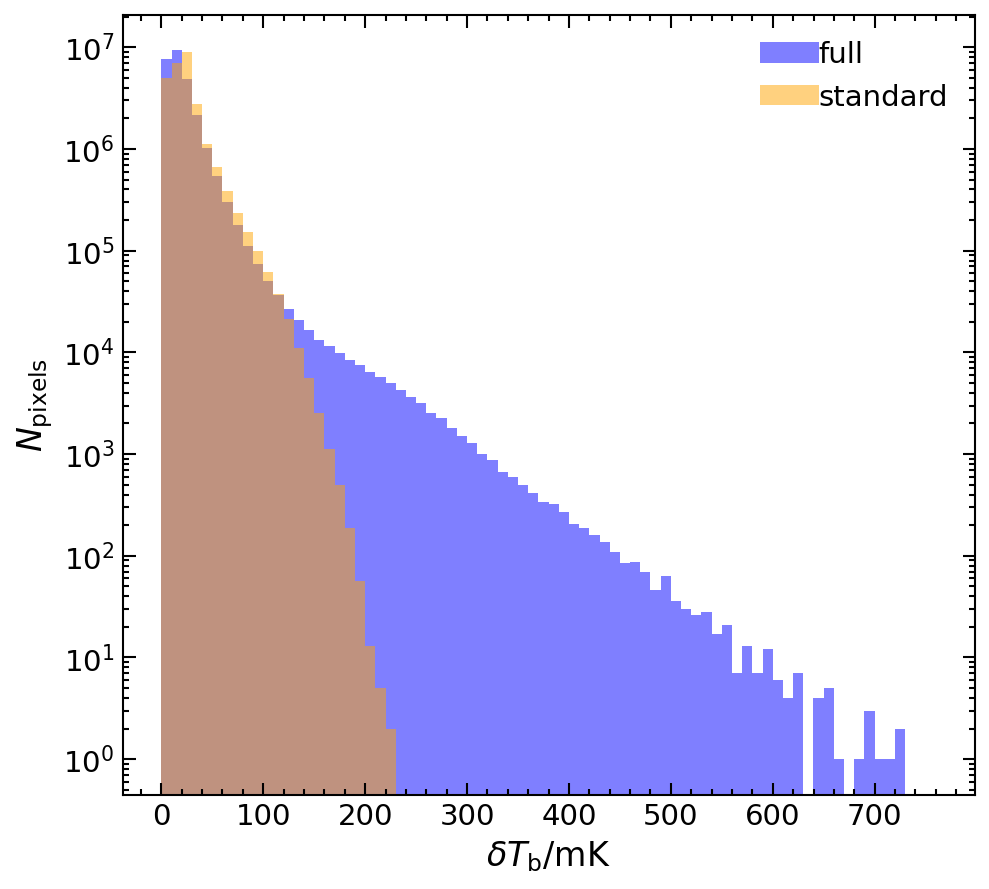

224.58088397979736
769.2245244979858
0.11104545970954517


In [9]:
i0 = 0
i1 = 101

BINS = np.arange(np.min([LC_z01_nu01_1deg[:,:,i0:i1], RSD_z01_nu01_1deg[:,:,i0:i1]]), np.max([LC_z01_nu01_1deg[:,:,i0:i1], RSD_z01_nu01_1deg[:,:,i0:i1]]),10.0)

fig, ax = plt.subplots(figsize=(fig_width, fig_height),
                       nrows=1, ncols=1,)
ax.hist(RSD_z01_nu01_1deg[:,:,i0:i1].reshape((512*512*101)), bins=BINS, color='blue', alpha=0.5, label='full')
ax.hist(LC_z01_nu01_1deg[:,:,i0:i1].reshape((512*512*101)), bins=BINS, color='orange', alpha=0.5, label='standard')
ax.set_yscale('log')
ax.set_ylabel(r'$N_{\rm pixels}$', fontsize=16)
ax.set_xlabel(r'$\delta T_{\rm b} /\rm mK$', fontsize=16)
plt.legend(frameon=False, fontsize=14)
plt.tight_layout()
plt.savefig(base + 'graphs_for_paper/EoR_deltaTb_hist.pdf', dpi=330)
plt.show()
print(np.max(LC_z01_nu01_1deg[:,:,i0:i1]))
print(np.max(RSD_z01_nu01_1deg[:,:,i0:i1]))
#percentage of pixels greater than 300
subset = np.where(RSD_z01_nu01_1deg[:,:,i0:i1].reshape(512*512*101)>np.max(LC_z01_nu01_1deg[:,:,i0:i1]))
print((len(np.array(subset).T)/len(RSD_z01_nu01_1deg[:,:,i0:i1].reshape((512*512*101))))*100)

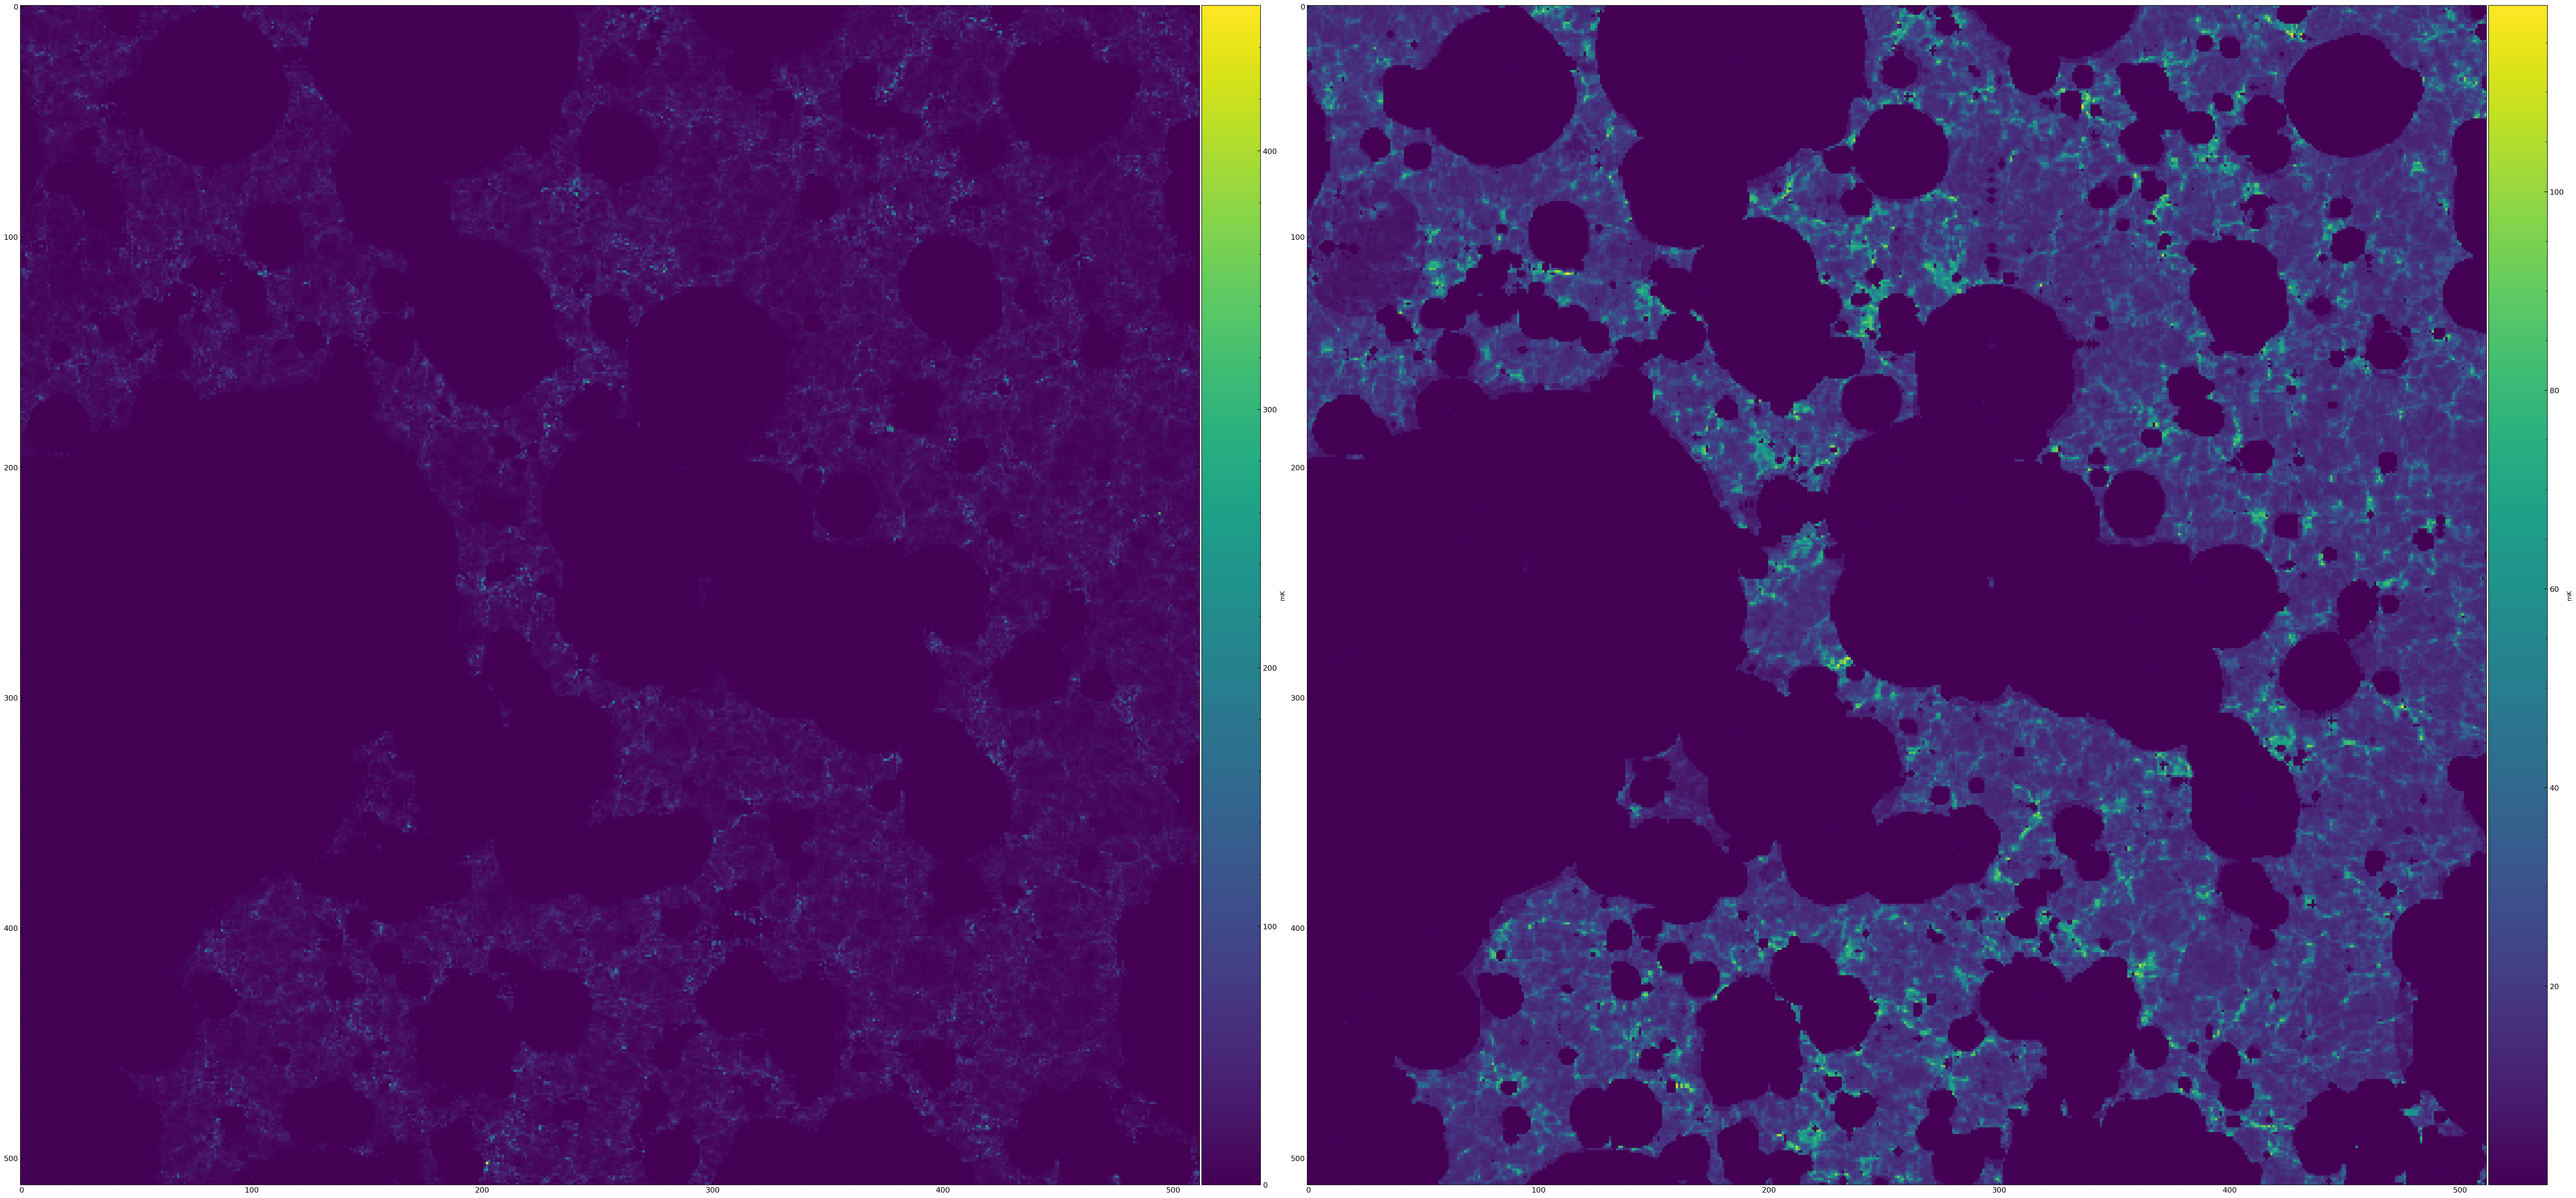

In [11]:
idx = 300
fig, ax = plt.subplots(figsize=(fig_width*10, fig_height*10),
                       nrows=1, ncols=2,)
pmc = ax[0].imshow(RSD_z01_nu01_1deg[:,:,idx])
divider = make_axes_locatable(ax[0])
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(pmc, cax=cax, orientation='vertical', label='mK')
pmc = ax[1].imshow(LC_z01_nu01_1deg[:,:,idx])
divider = make_axes_locatable(ax[1])
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(pmc, cax=cax, orientation='vertical', label='mK')
plt.tight_layout()
plt.show()


plt.imshow(LC_z01_nu01_1deg[:,:,300])

i0 = 0
i1 = 101

i2 = 300
i3 = 401

BINS = np.arange(np.min([RSD_z1_nu01_1deg[:,:,i0:i1], LC_z1_nu01_1deg[:,:,i0:i1], RSD_z05_nu01_1deg[:,:,i0:i1], LC_z05_nu01_1deg[:,:,i0:i1], RSD_z01_nu01_1deg[:,:,i0:i1], LC_z01_nu01_1deg[:,:,i0:i1]]), np.max([RSD_z1_nu01_1deg[:,:,i0:i1], LC_z1_nu01_1deg[:,:,i0:i1], RSD_z05_nu01_1deg[:,:,i0:i1], LC_z05_nu01_1deg[:,:,i0:i1], RSD_z01_nu01_1deg[:,:,i0:i1], LC_z01_nu01_1deg[:,:,i0:i1]]),10.0)

BINS2 = np.arange(np.min([RSD_z1_nu01_1deg[:,:,i2:i3], LC_z1_nu01_1deg[:,:,i2:i3], RSD_z05_nu01_1deg[:,:,i2:i3], LC_z05_nu01_1deg[:,:,i2:i3], RSD_z01_nu01_1deg[:,:,i2:i3], LC_z01_nu01_1deg[:,:,i2:i3]]), np.max([RSD_z1_nu01_1deg[:,:,i2:i3], LC_z1_nu01_1deg[:,:,i2:i3], RSD_z05_nu01_1deg[:,:,i2:i3], LC_z05_nu01_1deg[:,:,i2:i3], RSD_z01_nu01_1deg[:,:,i2:i3], LC_z01_nu01_1deg[:,:,i2:i3]]),10.0)

fig, ax = plt.subplots(figsize=(fig_width*2, fig_height),
                       nrows=1, ncols=2,)
fig.subplots_adjust(wspace=0)
ax[0].hist(RSD_z1_nu01_1deg[:,:,i0:i1].reshape((512*512*101)), bins=BINS, color='green', histtype='step', alpha=0.5, label=r'$\Delta z = 1.0$ full')
ax[0].hist(LC_z1_nu01_1deg[:,:,i0:i1].reshape((512*512*101)), bins=BINS, color='red', histtype='step', alpha=0.5, label=r'$\Delta z = 1.0$ standard')
ax[0].hist(RSD_z05_nu01_1deg[:,:,i0:i1].reshape((512*512*101)), bins=BINS, color='blue', histtype='step', alpha=0.5, label=r'$\Delta z = 0.5$  full')
ax[0].hist(LC_z05_nu01_1deg[:,:,i0:i1].reshape((512*512*101)), bins=BINS, color='orange', histtype='step', alpha=0.5, label=r'$\Delta z = 0.5$ standard')
ax[0].hist(RSD_z01_nu01_1deg[:,:,i0:i1].reshape((512*512*101)), bins=BINS, histtype='step', color='k', alpha=0.5, label=r'$\Delta z = 0.1$ full')
ax[0].hist(LC_z01_nu01_1deg[:,:,i0:i1].reshape((512*512*101)), bins=BINS, color='purple', histtype='step', alpha=0.5, label=r'$\Delta z = 0.1$  standard')
ax[0].text(0.35,0.95, r'$\nu = 145 \rm MHz$',transform=ax[0].transAxes, ha='right', va='top', fontsize=14)
ax[0].set_yscale('log')
ax[0].set_ylabel(r'$N_{pixels}$', fontsize=16)
ax[0].set_xlabel(r'$\delta T_b /mK$', fontsize=16)
ax[0].texts

ax[1].hist(RSD_z1_nu01_1deg[:,:,i2:i3].reshape((512*512*101)), bins=BINS2, color='green', histtype='step', alpha=0.5, label=r'$\Delta z = 1.0$ full')
ax[1].hist(LC_z1_nu01_1deg[:,:,i2:i3].reshape((512*512*101)), bins=BINS2, color='red', histtype='step', alpha=0.5, label=r'$\Delta z = 1.0$ standard')
ax[1].hist(RSD_z05_nu01_1deg[:,:,i2:i3].reshape((512*512*101)), bins=BINS2, color='blue', histtype='step', alpha=0.5, label=r'$\Delta z = 0.5$  full')
ax[1].hist(LC_z05_nu01_1deg[:,:,i2:i3].reshape((512*512*101)), bins=BINS2, color='orange', histtype='step', alpha=0.5, label=r'$\Delta z = 0.5$ standard')
ax[1].hist(RSD_z01_nu01_1deg[:,:,i2:i3].reshape((512*512*101)), bins=BINS2, histtype='step', color='k', alpha=0.5, label=r'$\Delta z = 0.1$ full')
ax[1].hist(LC_z01_nu01_1deg[:,:,i2:i3].reshape((512*512*101)), bins=BINS2, color='purple', histtype='step', alpha=0.5, label=r'$\Delta z = 0.1$  standard')
ax[1].text(0.35,0.95, r'$\nu = 175 \rm MHz$',transform=ax[1].transAxes, ha='right', va='top', fontsize=14)
ax[1].set_yscale('log')
ax[1].set_ylabel(r'$N_{pixels}$', fontsize=16)
ax[1].set_xlabel(r'$\delta T_b /mK$', fontsize=16)

ax[0].legend(frameon=False, fontsize=14)
plt.tight_layout()
plt.savefig(base+'graphs_for_paper/zbox_spacing_hist.pdf', dpi=330)
plt.show()

In [9]:
freq = np.arange(140, 180.1, 0.1)

z = np.arange(6.0, 10.0, 0.1)

nu = NuFromz(z)

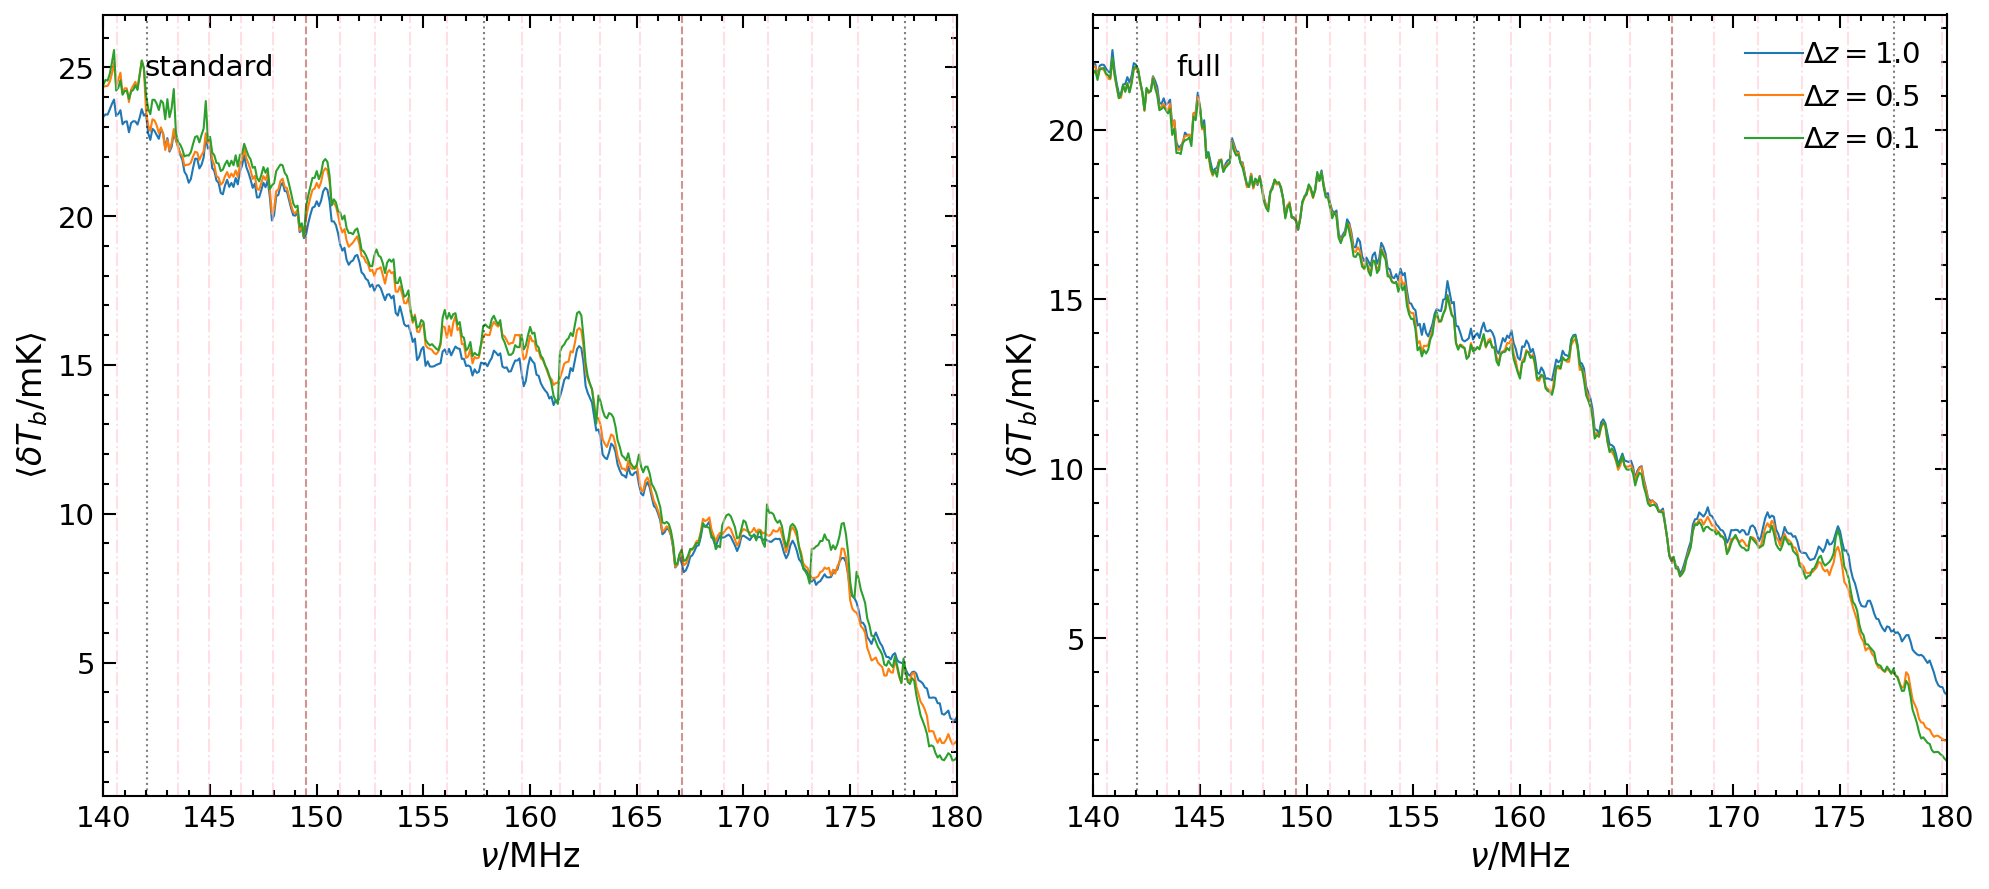

In [12]:
TB_RSD_z1_nu01_1deg = np.empty([RSD_z1_nu01_1deg.shape[2]])
TB_LC_z1_nu01_1deg = np.empty([LC_z1_nu01_1deg.shape[2]])
TB_RSD_z05_nu01_1deg = np.empty([RSD_z05_nu01_1deg.shape[2]])
TB_LC_z05_nu01_1deg = np.empty([LC_z05_nu01_1deg.shape[2]])
TB_RSD_z01_nu01_1deg = np.empty([RSD_z01_nu01_1deg.shape[2]])
TB_LC_z01_nu01_1deg = np.empty([LC_z01_nu01_1deg.shape[2]])

for ii in range(0,LC_z01_nu01_1deg.shape[2]):
    TB_RSD_z1_nu01_1deg[ii] = np.mean(RSD_z1_nu01_1deg[:,:,ii])
    TB_LC_z1_nu01_1deg[ii] = np.mean(LC_z1_nu01_1deg[:,:,ii])
    TB_RSD_z05_nu01_1deg[ii] = np.mean(RSD_z05_nu01_1deg[:,:,ii])
    TB_LC_z05_nu01_1deg[ii] = np.mean(LC_z05_nu01_1deg[:,:,ii])
    TB_RSD_z01_nu01_1deg[ii] = np.mean([RSD_z01_nu01_1deg[:,:,ii]])
    TB_LC_z01_nu01_1deg[ii] = np.mean([LC_z01_nu01_1deg[:,:,ii]])


fig, ax = plt.subplots(figsize=(fig_width*2, fig_height),
                       nrows=1, ncols=2,)
ax[0].plot(freq, TB_LC_z1_nu01_1deg, label=r'$\Delta z =1.0 $')
ax[0].plot(freq, TB_LC_z05_nu01_1deg, label=r'$\Delta z =0.5 $')
ax[0].plot(freq, TB_LC_z01_nu01_1deg, label=r'$\Delta z =0.1 $')
ax[0].set_ylabel(r'$ \langle \delta T_b / \rm mK \rangle$', fontsize=16)
ax[0].set_xlabel(r'$\nu / \rm MHz$', fontsize=16)
ax[0].text(0.2,0.95, 'standard',transform=ax[0].transAxes, ha='right', va='top', fontsize=14)
ax[0].set_xlim(140,180)
lines = ['dotted', 'dashdot', 'dashdot', 'dashdot', 'dashdot', 'dashed', 'dashdot', 'dashdot', 'dashdot', 'dashdot']
colors = ['k', 'pink', 'pink', 'pink', 'pink', 'brown', 'pink', 'pink', 'pink', 'pink']
lines = np.append(lines, lines)
lines = np.append(lines, lines)
colors = np.append(colors, colors)
colors = np.append(colors, colors)
for ii in range(0,len(nu)):
    ax[0].axvline(x = nu[ii], alpha=0.5, linestyle = lines[ii], color = colors[ii])

ax[1].plot(freq, TB_RSD_z1_nu01_1deg, label=r'$\Delta z =1.0 $')
ax[1].plot(freq, TB_RSD_z05_nu01_1deg, label=r'$\Delta z =0.5 $')
ax[1].plot(freq, TB_RSD_z01_nu01_1deg, label=r'$\Delta z =0.1 $')
ax[1].set_ylabel(r'$ \langle \delta T_b / \rm mK \rangle$', fontsize=16)
ax[1].text(0.15,0.95, 'full',transform=ax[1].transAxes, ha='right', va='top', fontsize=14)
ax[1].set_xlabel(r'$\nu / \rm MHz$', fontsize=16)
ax[1].set_xlim(140,180)
for ii in range(0,len(nu)):
    ax[1].axvline(x = nu[ii], alpha=0.5 , color = colors[ii], linestyle = lines[ii])
plt.tight_layout()
plt.legend(frameon=False, fontsize=14)
plt.savefig(base + 'graphs_for_paper/zbox_spacing_global_temp.pdf', dpi=330)
plt.show()

i0 = 0
i1 = 101

i2 = 300
i3 = 401

BINS = np.arange(0, 900,10.0)

BINS2 = np.arange(0, 700,10.0)

fig, ax = plt.subplots(figsize=(fig_width*2, fig_height),
                       nrows=1, ncols=2,)
fig.subplots_adjust(wspace=0)
ax[0].hist(RSD_z01_nu1_1deg[:,:,i0:11].reshape((512*512*11)), bins=BINS, color='green', histtype='step', alpha=0.5, label=r'$\Delta \nu = 1.0$ full', density =True)
ax[0].hist(LC_z01_nu1_1deg[:,:,i0:11].reshape((512*512*11)), bins=BINS, color='red', histtype='step', alpha=0.5, label=r'$\Delta \nu = 1.0$ standard', density =True)
ax[0].hist(RSD_z01_nu05_1deg[:,:,i0:21].reshape((512*512*21)), bins=BINS, color='blue', histtype='step', alpha=0.5, label=r'$\Delta \nu = 0.5$  full', density =True)
ax[0].hist(LC_z01_nu05_1deg[:,:,i0:21].reshape((512*512*21)), bins=BINS, color='orange', histtype='step', alpha=0.5, label=r'$\Delta \nu = 0.5$ standard', density =True)
ax[0].hist(RSD_z01_nu01_1deg[:,:,i0:i1].reshape((512*512*101)), bins=BINS, color='k', histtype='step', alpha=0.5, label=r'$\Delta \nu = 0.1$ full', density =True)
ax[0].hist(LC_z01_nu01_1deg[:,:,i0:i1].reshape((512*512*101)), bins=BINS, color='purple', histtype='step', alpha=0.5, label=r'$\Delta \nu = 0.1$  standard', density =True)
ax[0].text(0.35,0.95, r'$\nu = 145 \rm MHz$',transform=ax[0].transAxes, ha='right', va='top', fontsize=14)
ax[0].set_yscale('log')
ax[0].set_ylabel(r'$\rm PDF$', fontsize=16)
ax[0].set_xlabel(r'$\delta T_b / \rm mK$', fontsize=16)
ax[0].texts

ax[1].hist(RSD_z01_nu1_1deg[:,:,30:41].reshape((512*512*11)), bins=BINS2, color='green', histtype='step', alpha=0.5, label='z space 1 full', density =True)
ax[1].hist(LC_z01_nu1_1deg[:,:,30:41].reshape((512*512*11)), bins=BINS2, color='red', histtype='step', alpha=0.5, label='z space 1 standard', density =True)
ax[1].hist(RSD_z01_nu05_1deg[:,:,60:81].reshape((512*512*21)), bins=BINS2, color='blue', histtype='step', alpha=0.5, label='z space 0.5 full', density =True)
ax[1].hist(LC_z01_nu05_1deg[:,:,60:81].reshape((512*512*21)), bins=BINS2, color='orange', histtype='step', alpha=0.5, label='z space 0.5 standard', density =True)
ax[1].hist(RSD_z01_nu01_1deg[:,:,i2:i3].reshape((512*512*101)), bins=BINS2, histtype='step', color='k', alpha=0.5, label='z space 0.1 full', density =True)
ax[1].hist(LC_z01_nu01_1deg[:,:,i2:i3].reshape((512*512*101)), bins=BINS2, color='purple', histtype='step', alpha=0.5, label='z space 0.1 standard', density =True)
ax[1].text(0.35,0.95, r'$\nu = 175 \rm MHz$',transform=ax[1].transAxes, ha='right', va='top', fontsize=14)
ax[1].set_yscale('log')
ax[1].set_ylabel(r'$\rm PDF$', fontsize=16)
ax[1].set_xlabel(r'$\delta T_b /\rm mK$', fontsize=16)

ax[0].legend(frameon=False, fontsize=14)
plt.tight_layout()
plt.savefig(base + 'graphs_for_paper/freq_resolution_hist.pdf', dpi=330)
plt.show()

freq01 = np.arange(140, 180.1, 0.1)
freq05 = np.arange(140, 180.5, 0.5)
freq1 = np.arange(140, 181, 1)

TB_LC_z01_nu1_1deg = np.empty([LC_z01_nu1_1deg.shape[2]])
TB_RSD_z01_nu1_1deg = np.empty([RSD_z01_nu1_1deg.shape[2]])
TB_RSD_z01_nu05_1deg = np.empty([RSD_z01_nu05_1deg.shape[2]])
TB_LC_z01_nu05_1deg = np.empty([LC_z01_nu05_1deg.shape[2]])
TB_RSD_z01_nu01_1deg = np.empty([RSD_z01_nu01_1deg.shape[2]])
TB_LC_z01_nu01_1deg = np.empty([LC_z01_nu01_1deg.shape[2]])

for ii in range(0,RSD_z01_nu01_1deg.shape[2]):
    TB_LC_z01_nu01_1deg[ii] = np.mean(LC_z01_nu01_1deg[:,:,ii])
    TB_RSD_z01_nu01_1deg[ii] = np.mean(RSD_z01_nu01_1deg[:,:,ii])
for ii in range(0,RSD_z01_nu05_1deg.shape[2]):
    TB_RSD_z01_nu05_1deg[ii] = np.mean(RSD_z01_nu05_1deg[:,:,ii])
    TB_LC_z01_nu05_1deg[ii] = np.mean(LC_z01_nu05_1deg[:,:,ii])
for ii in range(0,RSD_z01_nu1_1deg.shape[2]):
    TB_LC_z01_nu1_1deg[ii] = np.mean([LC_z01_nu1_1deg[:,:,ii]])
    TB_RSD_z01_nu1_1deg[ii] = np.mean([RSD_z01_nu1_1deg[:,:,ii]])
    
    


fig, ax = plt.subplots(figsize=(fig_width*2, fig_height),
                       nrows=1, ncols=2,)
ax[0].plot(freq1, TB_LC_z01_nu1_1deg, label=r'$\Delta \nu = 1.0 $')
ax[0].plot(freq05, TB_LC_z01_nu05_1deg, label=r'$\Delta \nu = 0.5 $')
ax[0].plot(freq01, TB_LC_z01_nu01_1deg, label=r'$\Delta \nu =0.1 $')
ax[0].set_ylabel(r'$\langle \delta T_B /\rm mK \rangle $', fontsize=14)
ax[0].text(0.2,0.15, 'standard',transform=ax[0].transAxes, ha='right', va='top', fontsize=13)
ax[0].set_xlabel(r'$\nu / \rm MHz$', fontsize=14)
ax[0].set_xlim(140,180)
ax[1].plot(freq1, TB_RSD_z01_nu1_1deg, label=r'$\Delta \nu = 1.0 $ ')
ax[1].plot(freq05, TB_RSD_z01_nu05_1deg, label=r'$\Delta \nu = 0.5 $ ')
ax[1].plot(freq01, TB_RSD_z01_nu01_1deg, label=r'$\Delta \nu =0.1 $ ')
ax[1].set_ylabel(r'$\langle \delta T_B /\rm mK \rangle $', fontsize=14)
ax[1].text(0.15,0.15, 'full',transform=ax[1].transAxes, ha='right', va='top', fontsize=13)
ax[1].set_xlabel(r'$\nu / \rm MHz$', fontsize=14)
ax[1].set_xlim(140,180)
plt.tight_layout()
plt.legend(frameon=False, fontsize=14)
plt.savefig(base + 'graphs_for_paper/freq_resolution_global_temp.pdf', dpi=330)
plt.show()

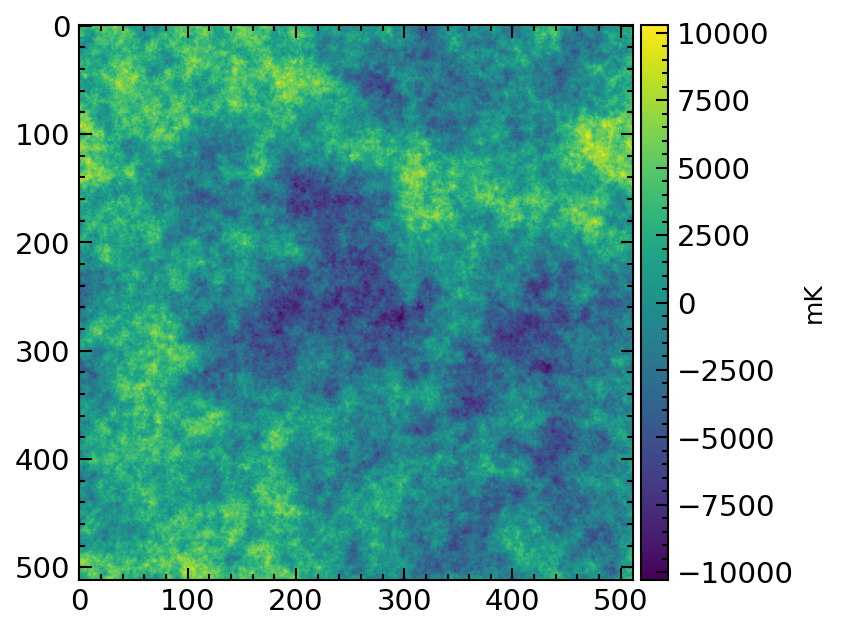

In [10]:
base = '/home/ppxjf3/RSD_LC/comparison/FINAL_LIGHTCONES_PEC_VEL_PAPER/'
with fits.open(base + 'Fg_N512_FOV1.0_140_180.0MHz_0.1MHz.fits', memmap=True) as hdu:
    FG = np.array(hdu[0].data)  
    
FG=FG*1e3
fig, ax = plt.subplots(1,1)
pmc_lc_cd = ax.imshow(FG[:,:,100])
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(pmc_lc_cd, cax=cax, orientation='vertical', label='mK')

In [11]:
FG_LC = FG + LC_z01_nu01_1deg
FG_RSD = FG + RSD_z01_nu01_1deg

In [12]:
c = 4
freq = np.arange(140, 180.1, 0.1)
model1, resids_LC_FG = do_fastica(FG_LC, c)
model2, resids_RSD_FG = do_fastica(FG_RSD, c)




print('correlation between model from each lc {}'.format(pearson_correl(model1,model2)))

correlation_graph(LC_z01_nu01_1deg, RSD_z01_nu01_1deg, resids_LC_FG, resids_RSD_FG, freq, 'EoR_Fg_4c_fastica_recovery_corre.pdf')

In [13]:
from scipy import interpolate
import matplotlib.colors as colors

plotting_scale={'x': 'log', 'y': 'log', 'z': 'log'}

bins = 8
  
i0 = 0
i1 = 101  

L_para, L_perp = get_lengths(freq[i0], freq[i1], (freq[i0]+freq[i1])/2, 1.0)
box_dims = [L_perp, L_perp, L_para]


pp_RSD, kper_RSD, kpar_RSD, n_RSD = t2c.power_spectrum_2d(RSD_z01_nu01_1deg[:,:,i0:i1], kbins=bins, box_dims= box_dims, return_modes=True)
for ii in range(0,len(kper_RSD)):
    for jj in range(0,len(kpar_RSD)):
        pp_RSD[ii,jj] = (pp_RSD[ii,jj]*np.sqrt(kper_RSD[ii]**2+kpar_RSD[jj]**2)**3)/(2*np.pi**2)

fp_RSD = interpolate.interp2d(kper_RSD, kpar_RSD, pp_RSD.T, kind='linear')
X_RSD, Y_RSD = kper_RSD, kpar_RSD
C_RSD = fp_RSD(X_RSD,Y_RSD)
norm_RSD = colors.LogNorm(vmin=C_RSD[np.isfinite(C_RSD)].min(), vmax=C_RSD[np.isfinite(C_RSD)].max()) if plotting_scale['z']=='log' else None 

pp_RSD_RES, kper_RSD_RES, kpar_RSD_RES, n_RSD_RES = t2c.power_spectrum_2d(resids_RSD_FG[:,:,i0:i1], kbins=bins, box_dims= box_dims, return_modes=True)
for ii in range(0,len(kper_RSD_RES)):
    for jj in range(0,len(kpar_RSD_RES)):
        pp_RSD_RES[ii,jj] = (pp_RSD_RES[ii,jj]*np.sqrt(kper_RSD_RES[ii]**2+ kpar_RSD_RES[jj]**2)**3)/(2*np.pi**2)
        
err_RSD_RES = 1/np.sqrt(n_RSD_RES)
fp_RSD_RES = interpolate.interp2d(kper_RSD_RES, kpar_RSD_RES, pp_RSD_RES.T, kind='linear')
X_RSD_RES, Y_RSD_RES = kper_RSD_RES, kpar_RSD_RES
C_RSD_RES = fp_RSD_RES(X_RSD_RES,Y_RSD_RES)
norm_RSD_RES = colors.LogNorm(vmin=C_RSD_RES[np.isfinite(C_RSD_RES)].min(), vmax=C_RSD_RES[np.isfinite(C_RSD_RES)].max()) if plotting_scale['z']=='log' else None 


pp_LC, kper_LC, kpar_LC, n_LC = t2c.power_spectrum_2d(LC_z01_nu01_1deg[:,:,i0:i1], kbins=bins, box_dims= box_dims, return_modes=True)
for ii in range(0,len(kper_LC)):
    for jj in range(0,len(kpar_LC)):
        pp_LC[ii,jj] = (pp_LC[ii,jj]*np.sqrt(kper_LC[ii]**2 + kpar_LC[jj]**2)**3)/(2*np.pi**2)
        
fp_LC = interpolate.interp2d(kper_LC, kpar_LC, pp_LC.T, kind='linear')
X_LC, Y_LC = kper_LC, kpar_LC
C_LC = fp_LC(X_LC,Y_LC)
norm_LC = colors.LogNorm(vmin=C_LC[np.isfinite(C_LC)].min(), vmax=C_LC[np.isfinite(C_LC)].max()) if plotting_scale['z']=='log' else None 


pp_LC_RES, kper_LC_RES, kpar_LC_RES, n_LC_RES = t2c.power_spectrum_2d(resids_LC_FG[:,:,i0:i1], kbins=bins, box_dims= box_dims, return_modes=True)
for ii in range(0,len(kper_LC_RES)):
    for jj in range(0,len(kpar_LC_RES)):
        pp_LC_RES[ii,jj] = (pp_LC_RES[ii,jj]*np.sqrt(kper_LC_RES[ii]**2 + kpar_LC_RES[jj]**2)**3)/(2*np.pi**2)
        
err_LC_RES = 1/np.sqrt(n_LC_RES)
fp_LC_RES = interpolate.interp2d(kper_LC_RES, kpar_LC_RES, pp_LC_RES.T, kind='linear')
X_LC_RES, Y_LC_RES = kper_LC_RES, kpar_LC_RES
C_LC_RES = fp_LC_RES(X_LC_RES,Y_LC_RES)
norm_LC_RES = colors.LogNorm(vmin=C_LC_RES[np.isfinite(C_LC_RES)].min(), vmax=C_LC_RES[np.isfinite(C_LC_RES)].max()) if plotting_scale['z']=='log' else None 

C_tot = np.concatenate((C_LC, C_RSD, C_LC_RES, C_RSD_RES))

norm_tot = colors.LogNorm(vmin=C_tot[np.isfinite(C_tot)].min(), vmax=C_tot[np.isfinite(C_tot)].max()) if plotting_scale['z']=='log' else None 

C_diff =(np.abs(C_RSD - C_LC)/C_LC)*100

norm_diff = colors.LogNorm(vmin=C_diff[np.isfinite(C_diff)].min(), vmax=C_diff[np.isfinite(C_diff)].max()) if plotting_scale['z']=='log' else None 


C_diff_res =  (np.abs(C_RSD_RES - C_LC_RES)/C_LC_RES)*100
norm_diff_res = colors.LogNorm(vmin=C_diff_res[np.isfinite(C_diff_res)].min(), vmax=C_diff_res[np.isfinite(C_diff_res)].max()) if plotting_scale['z']=='log' else None 

C_tot_diff = np.concatenate((C_diff, C_diff_res))
norm_tot_diff = colors.LogNorm(vmin=C_tot_diff[np.isfinite(C_tot_diff)].min(), vmax=C_tot_diff[np.isfinite(C_tot_diff)].max()) if plotting_scale['z']=='log' else None 


print(pearson_correl(C_diff_res.reshape(8*8),C_diff.reshape(8*8)))

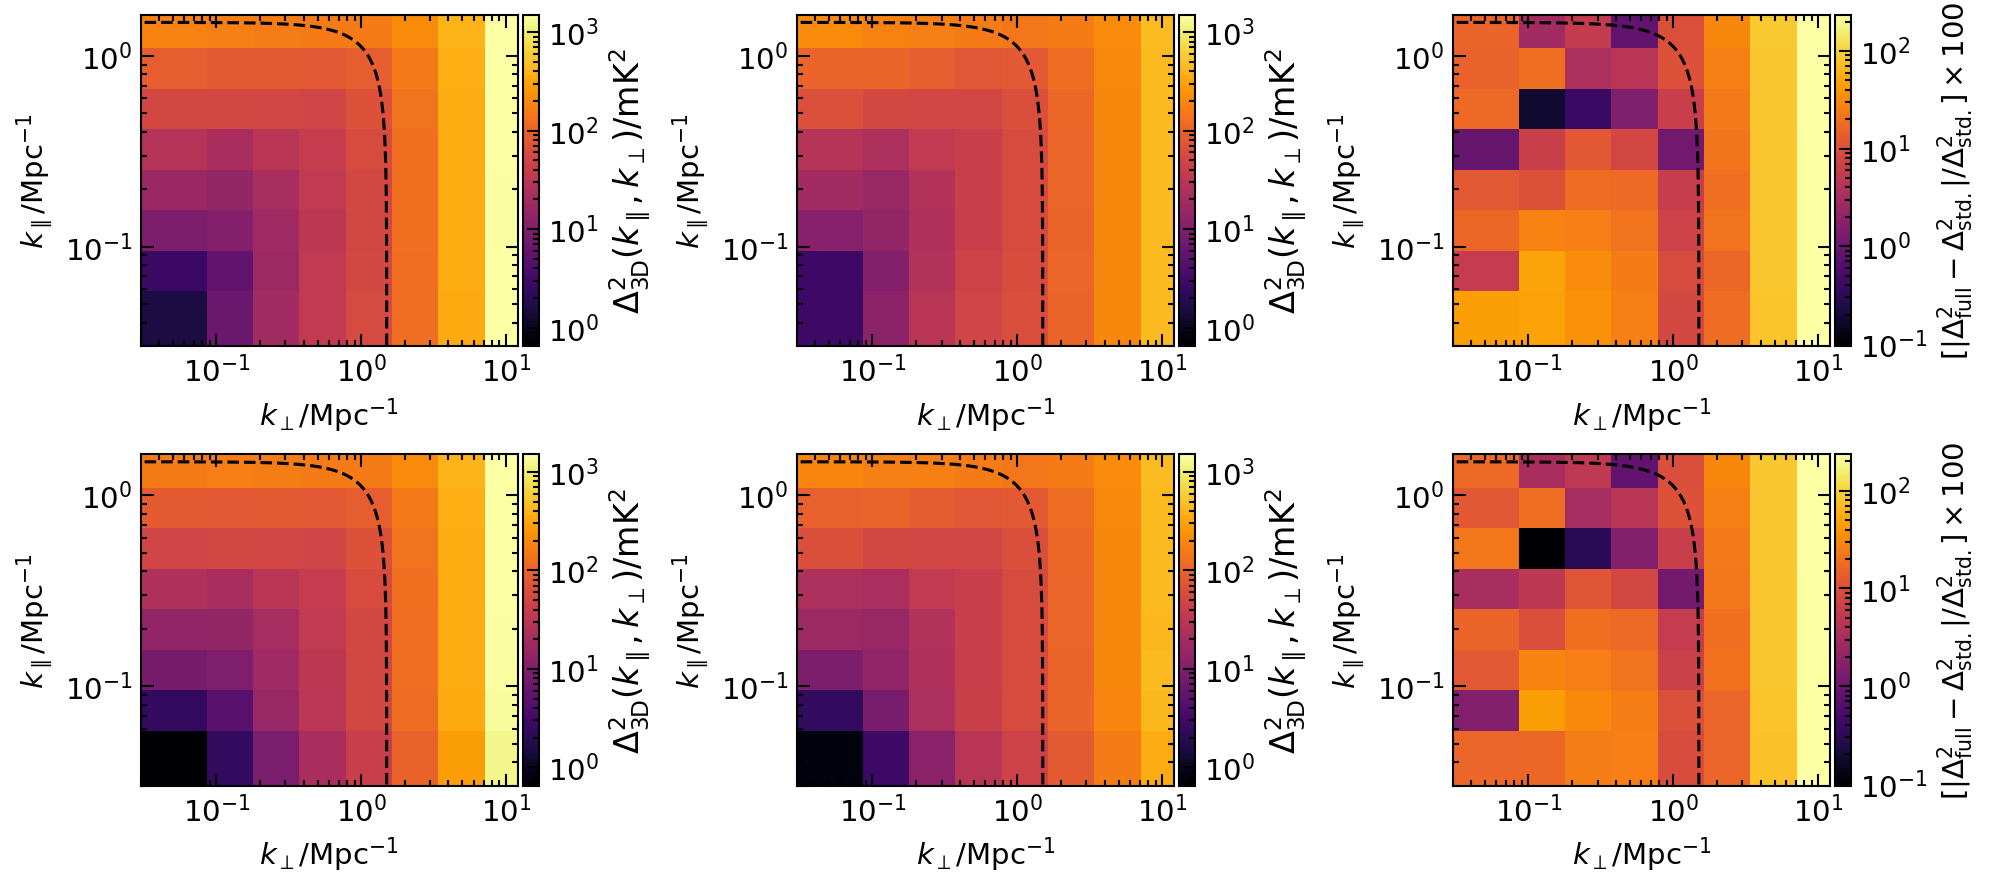

In [15]:

import matplotlib.font_manager
import matplotlib as mpl
import matplotlib.patches as patches

k_mag = 1.5
theta = np.linspace(0, 2*np.pi, 500)
k_par = k_mag * np.cos(theta)
k_perp = k_mag * np.sin(theta)
mask = (k_par > 0) & (k_perp > 0)

fig, ax = plt.subplots(figsize=(2*fig_width, fig_height),
                       nrows=2, ncols=3,)
    

pcm_RSD = ax[0,0].pcolormesh(X_RSD, Y_RSD, C_RSD, norm=norm_tot, cmap='inferno')
cbar= plt.colorbar(pcm_RSD, ax=ax[0,0], pad=0.01)
cbar.set_label(r'$\Delta_{\rm 3D}^2 (k_{\parallel}, k_{\perp}) /\rm mK^2 $', size=16) 
ax[0,0].set_xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$', fontsize = 14)
ax[0,0].set_ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$', fontsize = 14)
ax[0,0].set_xscale(plotting_scale['x'])
ax[0,0].set_yscale(plotting_scale['y'])
ax[0,0].plot(k_perp[mask], k_par[mask], color='k', lw=1.5, linestyle='--', label=r'$|\vec{k}| = 40$')
ax[0,0].set_ylim(0.03,1.65)
ax[0,0].set_xlim(left=0.03)

pcm_LC = ax[0,1].pcolormesh(X_LC, Y_LC, C_LC, norm=norm_tot, cmap='inferno')
cbar= plt.colorbar(pcm_LC, ax=ax[0,1], pad=0.01)
cbar.set_label(r'$\Delta_{\rm 3D}^2 (k_{\parallel}, k_{\perp}) /\rm mK^2 $', size=16) 
ax[0,1].set_xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$', fontsize = 14)
ax[0,1].set_ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$', fontsize = 14)
ax[0,1].set_xscale(plotting_scale['x'])
ax[0,1].set_yscale(plotting_scale['y'])
ax[0,1].plot(k_perp[mask], k_par[mask], color='k', lw=1.5, linestyle='--', label=r'$|\vec{k}| = 40$')
ax[0,1].set_ylim(0.03,1.65)  
ax[0,1].set_xlim(left=0.03)

pcm_LC = ax[0,2].pcolormesh(X_LC, Y_LC, C_diff, norm=norm_tot_diff, cmap='inferno')
cbar= plt.colorbar(pcm_LC, ax=ax[0,2], pad=0.01)
cbar.set_label(r'$[|\Delta_{\rm full}^2 - \Delta^2_{\rm std.}|/\Delta^2_{\rm std.}] \times 100 $', size=14) 
ax[0,2].set_xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$', fontsize = 14)
ax[0,2].set_ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$', fontsize = 14)
ax[0,2].set_xscale(plotting_scale['x'])
ax[0,2].set_yscale(plotting_scale['y'])
ax[0,2].plot(k_perp[mask], k_par[mask], color='k', lw=1.5, linestyle='--', label=r'$|\vec{k}| = 40$')
ax[0,2].set_ylim(0.03,1.65)   
ax[0,2].set_xlim(left=0.03)

pcm_RSD_RES = ax[1,0].pcolormesh(X_RSD_RES, Y_RSD_RES, C_RSD_RES, norm=norm_tot, cmap='inferno')
cbar= plt.colorbar(pcm_RSD_RES, ax=ax[1,0], pad=0.01)
cbar.set_label(r'$\Delta_{\rm 3D}^2 (k_{\parallel}, k_{\perp}) /\rm mK^2 $', size=16) 
ax[1,0].set_xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$', fontsize = 14)
ax[1,0].set_ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$', fontsize = 14)
ax[1,0].set_xscale(plotting_scale['x'])
ax[1,0].set_yscale(plotting_scale['y'])
ax[1,0].plot(k_perp[mask], k_par[mask], color='k', lw=1.5, linestyle='--', label=r'$|\vec{k}| = 40$')
ax[1,0].set_ylim(0.03,1.64)
ax[1,0].set_xlim(left=0.03)

pcm_LC_RES = ax[1,1].pcolormesh(X_LC_RES, Y_LC_RES, C_LC_RES, norm=norm_tot, cmap='inferno')
cbar= plt.colorbar(pcm_LC_RES, ax=ax[1,1], pad=0.01)
cbar.set_label(r'$\Delta_{\rm 3D}^2 (k_{\parallel}, k_{\perp}) /\rm mK^2 $', size=16) 
ax[1,1].set_xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$', fontsize = 14)
ax[1,1].set_ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$', fontsize = 14)
ax[1,1].set_xscale(plotting_scale['x'])
ax[1,1].set_yscale(plotting_scale['y'])
ax[1,1].plot(k_perp[mask], k_par[mask], color='k', lw=1.5, linestyle='--', label=r'$|\vec{k}| = 40$')
ax[1,1].set_ylim(0.03,1.64)
ax[1,1].set_xlim(left=0.03)  

pcm_LC_RES = ax[1,2].pcolormesh(X_LC_RES, Y_LC_RES, C_diff_res, norm=norm_tot_diff, cmap='inferno')
cbar= plt.colorbar(pcm_LC_RES, ax=ax[1,2], pad=0.01)
cbar.set_label(r'$[|\Delta^2_{\rm full} - \Delta^2_{\rm std.}|/\Delta^2_{\rm std.}] \times 100 $', size=14) 
ax[1,2].set_xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$', fontsize = 14)
ax[1,2].set_ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$', fontsize = 14)
ax[1,2].set_xscale(plotting_scale['x'])
ax[1,2].set_yscale(plotting_scale['y'])
ax[1,2].plot(k_perp[mask], k_par[mask], color='k', lw=1.5, linestyle='--', label=r'$|\vec{k}| = 40$')
ax[1,2].set_ylim(0.03,1.64)
ax[1,2].set_xlim(left=0.03)

plt.tight_layout()
plt.savefig(base + 'graphs_for_paper/cyclindrical_powerSpec_FGremoval_512_160-170MHz.pdf', dpi=330, bbox_inches='tight')
plt.show()

In [34]:
kbins=15
mubins=15
    
Pk_lc, mubins_lc, kbins_lc, nmode_lc = t2c.power_spectrum_mu(LC_z01_nu01_1deg[:,:,i0:i1], los_axis = 2, box_dims=box_dims, mubins=mubins,kbins=kbins, exclude_zero_modes=True,return_n_modes=True,absolute_mus=False)
Pk_reslc, mubins_reslc, kbins_reslc, nmode_reslc = t2c.power_spectrum_mu(resids_LC_FG[:,:,i0:i1], los_axis = 2, box_dims=box_dims, mubins=mubins,kbins=kbins, exclude_zero_modes=True,return_n_modes=True,absolute_mus=False)

Pk_rsd, mubins_rsd, kbins_rsd, nmode_rsd = t2c.power_spectrum_mu(RSD_z01_nu01_1deg[:,:,i0:i1], los_axis = 2, box_dims=box_dims, mubins=mubins,kbins=kbins, exclude_zero_modes=True,return_n_modes=True,absolute_mus=False)
Pk_resrsd, mubins_resrsd, kbins_resrsd, nmode_resrsd = t2c.power_spectrum_mu(resids_RSD_FG[:,:,i0:i1], box_dims=box_dims, los_axis = 2, mubins=mubins,kbins=kbins, exclude_zero_modes=True,return_n_modes=True,absolute_mus=False)


In [35]:
dk_lc = (Pk_lc*kbins_lc**3)/(2*np.pi**2)
dk_rsd = (Pk_rsd*kbins_rsd**3)/(2*np.pi**2)
dk_lc_res = (Pk_reslc*kbins_reslc**3)/(2*np.pi**2)
dk_rsd_res = (Pk_resrsd*kbins_resrsd**3)/(2*np.pi**2)


In [36]:
#calculate errors
err_lc_res= np.empty_like(nmode_reslc)
err_rsd_res= np.empty_like(nmode_resrsd)

for ii in range(0,nmode_lc.shape[0]):
    for jj in range(0,nmode_lc.shape[1]):
        err_lc_res[ii, jj] = dk_lc_res[ii, jj]/np.sqrt(nmode_reslc[ii, jj])
        
        err_rsd_res[ii, jj] = dk_rsd_res[ii, jj]/np.sqrt(nmode_resrsd[ii,jj])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


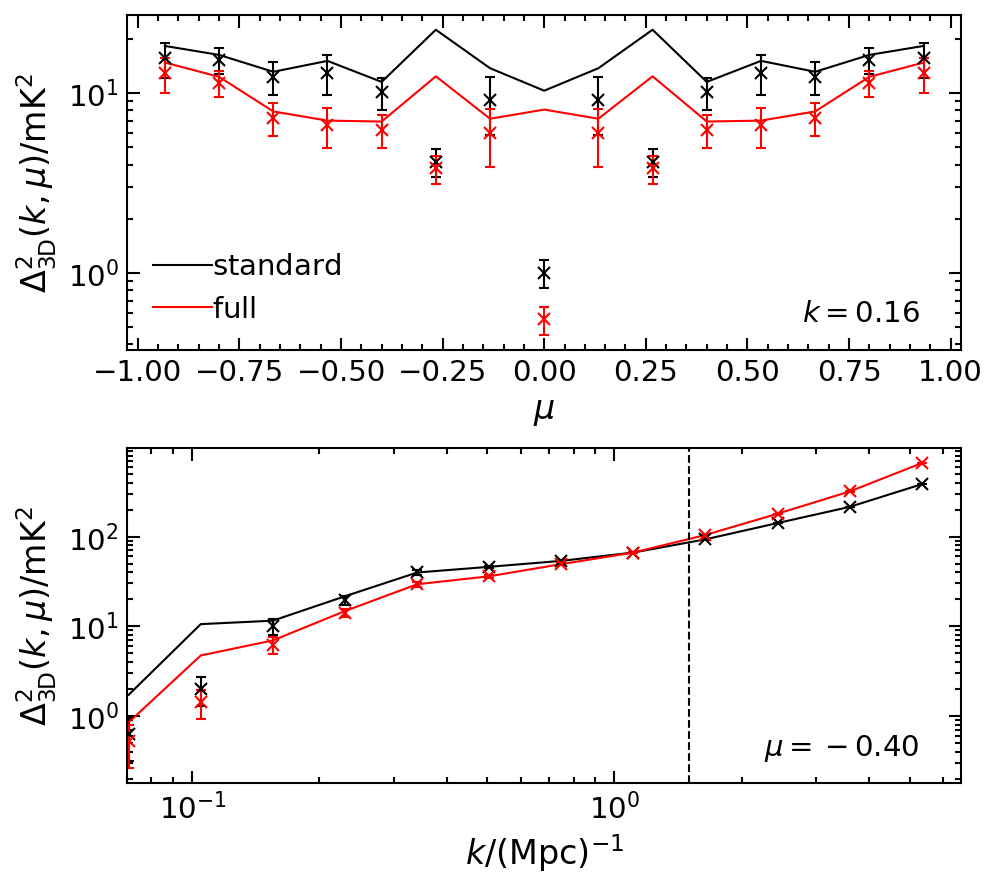

In [ ]:
ii = 3
jj = 4

import matplotlib.ticker as ticker

def format_ticks(value, pos):
    """Format ticks to show integers while maintaining the logarithmic scale."""
    exponent = int(np.log10(value))
    mantissa = value / (10 ** exponent)
    if np.isclose(mantissa, 1.0):  # Only show ticks at powers of ten
        return f'$10^{{{exponent}}}$'
    return ''

fig, ax = plt.subplots(figsize=(fig_width, fig_height), nrows=2, ncols=1)

# Upper panel
ax[0].plot(mubins_lc, dk_lc[:, ii], color='k', label=r'$\rm standard$')
ax[0].errorbar(mubins_lc, dk_lc_res[:, ii], err_lc_res[:, ii], color='k', ls='none', capsize=2.5, marker='x')
ax[0].plot(mubins_rsd, dk_rsd[:, ii], color='r', label=r'$\rm full$')
ax[0].errorbar(mubins_resrsd, dk_rsd_res[:, ii], err_rsd_res[:, ii], color='r', ls='none', capsize=2.5, marker='x')
ax[0].set_yscale('log')
ax[0].set_xlabel(r'$\mu$', fontsize=16)
ax[0].set_ylabel(r'$\Delta^2_{\rm 3D}(k,\mu)/ \rm mK^2$', fontsize=16)
ax[0].text(0.95, 0.15, r' $k={0:.2f}$'.format(kbins_lc[ii]), transform=ax[0].transAxes, ha='right', va='top', fontsize=14)
ax[0].legend(frameon=False, fontsize=14)


# Lower panel
ax[1].plot(kbins_lc, dk_lc[jj, :], color='k')
ax[1].errorbar(kbins_reslc, dk_lc_res[jj, :], err_lc_res[jj, :], color='k', ls='none', capsize=2.5, marker='x')
ax[1].plot(kbins_rsd, dk_rsd[jj, :], color='r')
ax[1].errorbar(kbins_resrsd, dk_rsd_res[jj, :], err_rsd_res[jj, :], color='r', ls='none', capsize=2.5, marker='x')
ax[1].set_xlabel(r'$k/(\rm Mpc)^{-1}$', fontsize=16)
ax[1].set_ylabel(r'$\Delta^2_{\rm 3D}(k,\mu)/ \rm mK^2$', fontsize=16)
ax[1].text(0.95, 0.15, r' $\mu={0:.2f}$'.format(mubins_lc[jj]), transform=ax[1].transAxes, ha='right', va='top', fontsize=14)
ax[1].set_yscale('log')
ax[1].set_xscale('log')
ax[1].axvline(1.5, linestyle='dashed', color='k', alpha=0.5)
ax[1].set_xlim(left = 0.07)
ax[1].legend(frameon=False, fontsize=14)

plt.tight_layout()
plt.savefig(base + 'graphs_for_paper/mu_ps_fg_removal.pdf', dpi=330)
plt.show()


print(dk_rsd_res[jj, 12])
print((np.abs(dk_rsd_res[jj, 12]-dk_lc_res[jj, 12])/dk_lc_res[jj, 12])*100)
print((np.abs(dk_rsd[jj, 12]-dk_lc[jj, 12])/dk_lc[jj, 12])*100)

kbins=15
i0 = 0
i1 = 101  

L_para, L_perp = get_lengths(freq[i0], freq[i1], (freq[i0]+freq[i1])/2, 1.0)
box_dims = [L_perp, L_perp, L_para]

V_eor = L_perp*L_perp*L_para #LC_Volume(freq[i0], freq[i1], 1.0)


p_lc_eor_res, k_lc_eor_res, n_lc_res = t2c.power_spectrum_1d(resids_LC_FG[:,:,i0:i1], kbins=kbins, box_dims=box_dims, binning =  'log', return_n_modes=True)
p_rsd_lc_eor_res, k_rsd_lc_eor_res, n_rsd_res = t2c.power_spectrum_1d(resids_RSD_FG[:,:,i0:i1], box_dims=box_dims, kbins=kbins, binning =  'log', return_n_modes=True)
p_lc_eor, k_lc_eor, n_lc = t2c.power_spectrum_1d(LC_z01_nu01_1deg[:,:,i0:i1], kbins=kbins, box_dims=box_dims, binning =  'log', return_n_modes=True)
p_rsd, k_rsd, n_rsd = t2c.power_spectrum_1d(RSD_z01_nu01_1deg[:,:,i0:i1], box_dims=box_dims, kbins=kbins, binning =  'log', return_n_modes=True)



d_lc = (p_lc_eor*V_eor*k_lc_eor**3)/(2*np.pi**2)
d_rsd = (p_rsd*V_eor*k_rsd**3)/(2*np.pi**2)
d_lc_res = (p_lc_eor_res*V_eor*k_lc_eor_res**3)/(2*np.pi**2)
d_rsd_res = (p_rsd_lc_eor_res*V_eor*k_rsd_lc_eor_res**3)/(2*np.pi**2)


#calculate errors
errors = np.loadtxt(base + 'errors_on_FastICA_EoR_1Dps.txt')
err_lc_res= errors[:,1]
err_rsd_res= errors[:,0]

"""
#for ii in range(0,n_lc_res.shape[0]):
    err_lc_res[ii] = d_lc_res[ii]/np.sqrt(n_lc_res[ii])
        
    #err_rsd_res[ii] = d_rsd_res[ii]/np.sqrt(n_rsd_res[ii])"""

#lightcone standard
fig, ax = plt.subplots(figsize=(fig_width, fig_height),
                       nrows=1, ncols=1,)

ax.plot(k_lc_eor, d_lc, color='k', label=r'$\rm standard$')
ax.plot(k_rsd, d_rsd, color='r', label=r'$\rm full$')
#ax.plot(k_lc_eor, d_lc, color='k')
ax.errorbar(k_lc_eor_res, d_lc_res, err_lc_res, color='k', ls='none', capsize = 2.5, marker='x')
ax.errorbar(k_rsd_lc_eor_res, d_rsd_res, err_rsd_res, color='r', ls='none', capsize = 2.5, marker='x')

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel(r'$k/(\rm Mpc/h)^{-1}$', fontsize=16)
ax.set_ylabel(r'$\Delta_{\rm 3D} ^2(k)/\rm mK^2$', fontsize = 16)
ax.legend(frameon=False, fontsize = 14)

plt.tight_layout()
plt.savefig(base + 'graphs_for_paper/eor_3d_ps_fg_removal.pdf', dpi=330)
plt.show()

print((np.abs(d_rsd[-1]-d_lc[-1])/d_lc[-1])*100)
print((np.abs(d_rsd_res[-1]-d_lc_res[-1])/d_lc_res[-1])*100)


In [12]:
#add noise
#with fits.open('NOISE_I_140-180_SKA_central_area_Rev3_EOR0_1.0_1000hrs.fits', memmap=True) as hdu:
with fits.open('Noise_N512_FOV1.000_140-180_1000hrs_SKA_all_stations_Rev3_EOR0_1.0_0512_natural_I_I.fits', memmap=True) as hdu:
    NOISE =np.array(hdu[0].data) #10MHz centered on 166MHz
    hdu.info()

NOISE = NOISE *1e3

"""with fits.open('Noise_N512_FOV1.000_140-180_2000hrs_SKA_all_stations_Rev3_EOR0_1.0_0512_natural_I_I.fits', memmap=True) as hdu:
    NOISE_2000 =np.array(hdu[0].data) #10MHz centered on 166MHz
    hdu.info()

NOISE_2000 = NOISE_2000 *1e3"""

#NOISE = np.transpose(NOISE, (1,2,0))

FG_LC_NOISE = FG_LC + NOISE
FG_RSD_NOISE = FG_RSD + NOISE

"""with fits.open('Noise_N512_FOV1.000_140-180_1000hrs_SKA_all_stations_Rev3_EOR0_1.0_0512_natural_I_3400m.fits', memmap=True) as hdu:
    NOISE2 =np.array(hdu[0].data) #10MHz centered on 166MHz
    hdu.info()

NOISE2 = NOISE2 *1e3"""

Filename: Noise_N512_FOV1.000_140-180_1000hrs_SKA_all_stations_Rev3_EOR0_1.0_0512_natural_I_I.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (401, 512, 512)   float64   


"with fits.open('Noise_N512_FOV1.000_140-180_1000hrs_SKA_all_stations_Rev3_EOR0_1.0_0512_natural_I_3400m.fits', memmap=True) as hdu:\n    NOISE2 =np.array(hdu[0].data) #10MHz centered on 166MHz\n    hdu.info()\n\nNOISE2 = NOISE2 *1e3"

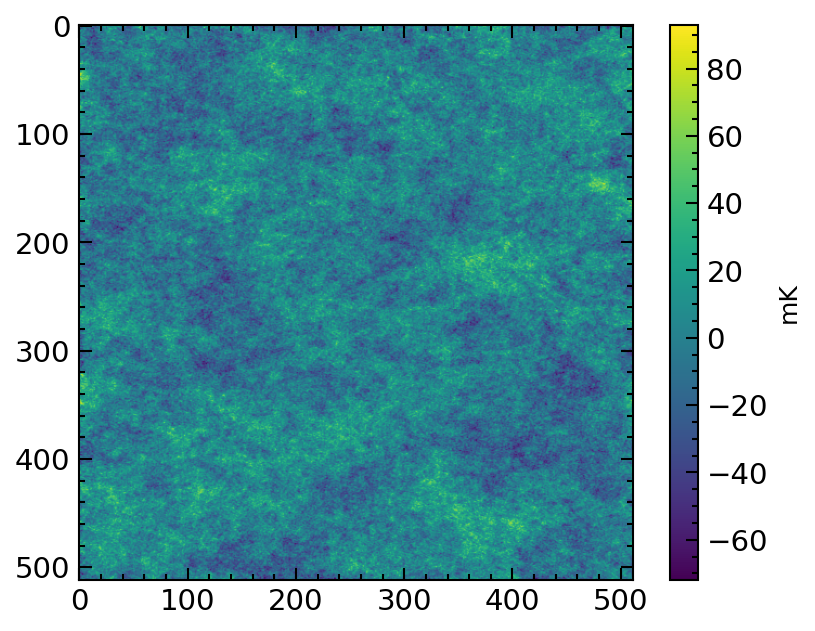

In [16]:
plt.imshow(NOISE[:,:,100])
plt.colorbar(label='mK')

4831053.054185755
163.5618036167657
[1.08327327e-04 3.52503399e-04 1.14706649e-03 3.73262081e-03
 1.21461644e-02 3.95243227e-02 1.28614436e-01 4.18518828e-01
 1.36188452e+00 4.43165114e+00 1.44208496e+01 4.69262801e+01
 1.52700835e+02 4.96897364e+02 1.61693281e+03]


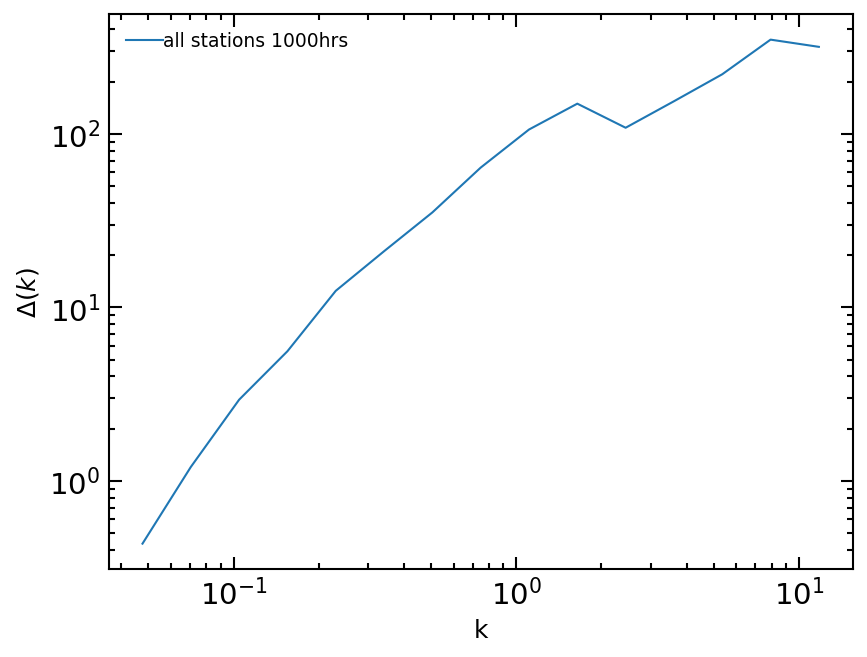

"p_NOISE, k_NOISE, n_NOISE = t2c.power_spectrum_1d(NOISE[:,:,i0:i1], box_dims=box_dims, kbins=kbins, binning = 'log', return_n_modes=True)\nd_NOISE = (p_NOISE*V_NOISE*k_NOISE**3)/(2*np.pi**2)\n\nplt.plot(k_NOISE, d_NOISE)\nplt.yscale('log')\nplt.xlabel('k')\nplt.xscale('log')\nplt.ylabel(r'$\\Delta(k)$')\nplt.show()\n\nplt.plot(k_NOISE, p_NOISE)\nplt.yscale('log')\nplt.xlabel('k')\nplt.xscale('log')\nplt.ylabel('P')\nplt.show()"

In [13]:

kbins=15
mubins=15


i0 =0

i1 =101

"""L_para, L_perp = get_lengths(freq[i0], freq[i0+1], (freq[i0]+freq[i0+1])/2, 1.0)
box_dims = [L_perp, L_perp, L_para]


    
V_NOISE = L_perp*L_perp*L_para

p_NOISE, k_NOISE, n_NOISE = t2c.power_spectrum_1d(NOISE[:,:,i0:i0+1], box_dims=box_dims, kbins=kbins, binning = 'log', return_n_modes=True)
d_NOISE = (p_NOISE*V_NOISE*k_NOISE**3)/(2*np.pi**2)

""""""

plt.plot(k_NOISE, d_NOISE)
plt.yscale('log')
plt.xlabel('k')
plt.xscale('log')
plt.ylabel(r'$\Delta(k)$')
plt.show()"""

L_para, L_perp = get_lengths(freq[i0], freq[i1], (freq[i0]+freq[i1])/2, 1.0)
box_dims = [L_perp, L_perp, L_para]
V_NOISE = L_perp*L_perp*L_para
print(V_NOISE)
print(L_perp)
p_NOISE, k_NOISE, n_NOISE = t2c.power_spectrum_1d(NOISE[:,:,i0:i1], box_dims=box_dims, kbins=kbins, binning = 'log', return_n_modes=True)
d_NOISE = (p_NOISE*(k_NOISE**3))/(2*np.pi**2)
print(k_NOISE**3)
"""p_NOISE_2000, k_NOISE_2000, n_NOISE_2000 = t2c.power_spectrum_1d(NOISE_2000[:,:,i0:i1], box_dims=box_dims, kbins=kbins, binning = 'log', return_n_modes=True)
d_NOISE_2000 = (p_NOISE_2000*(k_NOISE_2000**3))/(2*np.pi**2)"""

"""p_NOISE2, k_NOISE2, n2 = t2c.power_spectrum_1d(NOISE2[:,:,i0:i1], box_dims=box_dims, kbins=kbins, binning = 'log', return_n_modes=True)
d_NOISE2 = (p_NOISE2*V_NOISE*k_NOISE2**3)/(2*np.pi**2)
"""
plt.plot(k_NOISE, d_NOISE, label='all stations 1000hrs')
#plt.plot(k_NOISE_2000, d_NOISE_2000, label='all stations 2000hrs')
plt.yscale('log')
plt.xlabel('k')
plt.xscale('log')
plt.legend()
plt.ylabel(r'$\Delta(k)$')
plt.show()

"""p_NOISE, k_NOISE, n_NOISE = t2c.power_spectrum_1d(NOISE[:,:,i0:i1], box_dims=box_dims, kbins=kbins, binning = 'log', return_n_modes=True)
d_NOISE = (p_NOISE*V_NOISE*k_NOISE**3)/(2*np.pi**2)

plt.plot(k_NOISE, d_NOISE)
plt.yscale('log')
plt.xlabel('k')
plt.xscale('log')
plt.ylabel(r'$\Delta(k)$')
plt.show()

plt.plot(k_NOISE, p_NOISE)
plt.yscale('log')
plt.xlabel('k')
plt.xscale('log')
plt.ylabel('P')
plt.show()"""

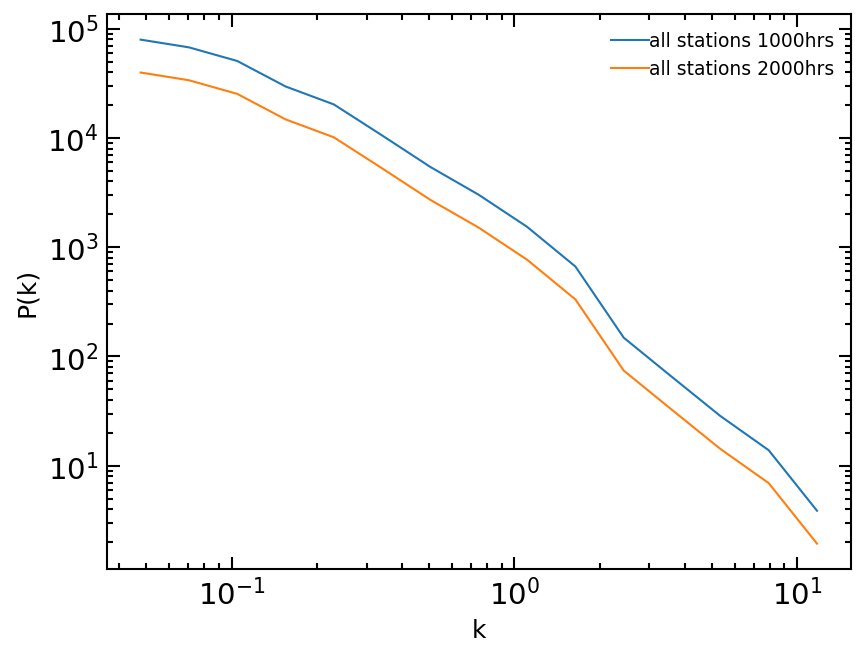

In [20]:
plt.plot(k_NOISE, p_NOISE, label='all stations 1000hrs')
plt.plot(k_NOISE_2000, p_NOISE_2000, label='all stations 2000hrs')
plt.yscale('log')
plt.xlabel('k')
plt.xscale('log')
plt.legend()
plt.ylabel(r'P(k)')
plt.show()

In [26]:
print(k_NOISE*k_NOISE*k_NOISE)

[1.08327327e-04 3.52503399e-04 1.14706649e-03 3.73262081e-03
 1.21461644e-02 3.95243227e-02 1.28614436e-01 4.18518828e-01
 1.36188452e+00 4.43165114e+00 1.44208496e+01 4.69262801e+01
 1.52700835e+02 4.96897364e+02 1.61693281e+03]




"""RMS = np.empty([NOISE.shape[2]])

for ii in range(0,NOISE.shape[2]):
    RMS[ii] = np.sqrt(np.mean(pow(NOISE[:,:,ii],2)))
    
plt.plot(freq, RMS)
plt.ylabel('RMS \mK')
plt.xlabel(r'$\nu$ \MHz')
plt.show()"""
    
z = zFromNu(freq[100])
L = cosmo.comoving_distance(z) * (np.pi * 1.0 / 180.0)
L = L.value

p_NOISE, k_NOISE, n_NOISE = t2c.power_spectrum_1d(NOISE[:,:,100], box_dims=L, kbins=kbins, binning = 'logarithmic', return_n_modes=True)
d_NOISE = (p_NOISE*k_NOISE**3)/(2*np.pi**2*pow(L,2))

plt.plot(k_NOISE, d_NOISE)
plt.yscale('log')
plt.xlabel('k')
plt.xscale('log')
plt.ylabel(r'$\Delta(k, 150 \rm MHz)$')
plt.show()

z = zFromNu(freq[200])
L = cosmo.comoving_distance(z) * (np.pi * 1.0 / 180.0)
L = L.value

p_NOISE, k_NOISE, n_NOISE = t2c.power_spectrum_1d(NOISE[:,:,200], box_dims=L, kbins=kbins, binning = 'logarithmic', return_n_modes=True)
d_NOISE = (p_NOISE*k_NOISE**3)/(2*np.pi**2*pow(L,2))

plt.plot(k_NOISE, d_NOISE)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('k')
plt.ylabel(r'$\Delta(k, 160 \rm MHz)$')
plt.show()

In [14]:

LC_NOISE = LC_z01_nu01_1deg + NOISE
RSD_NOISE = RSD_z01_nu01_1deg + NOISE

correlation between model from each lc 0.9999996079228921


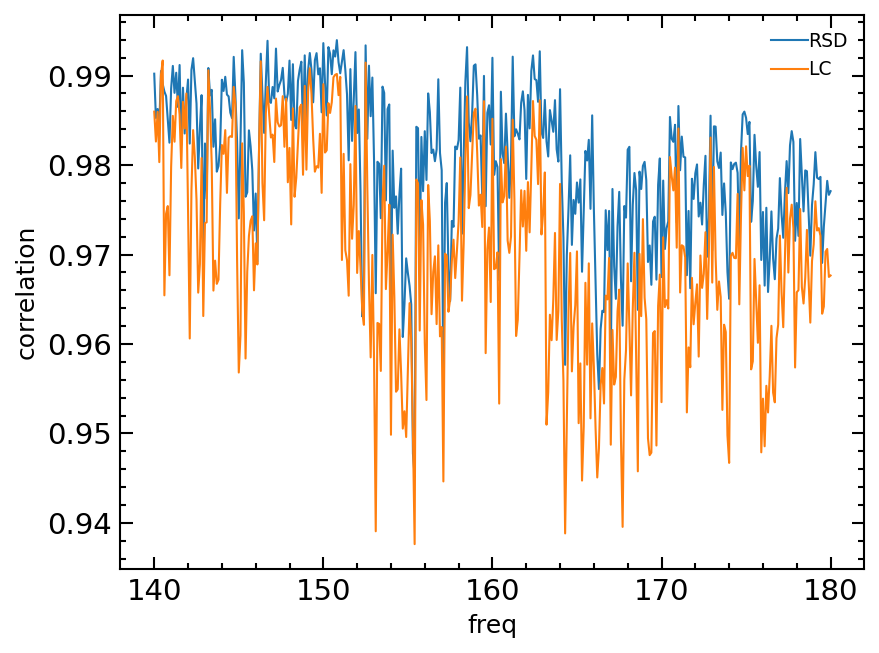

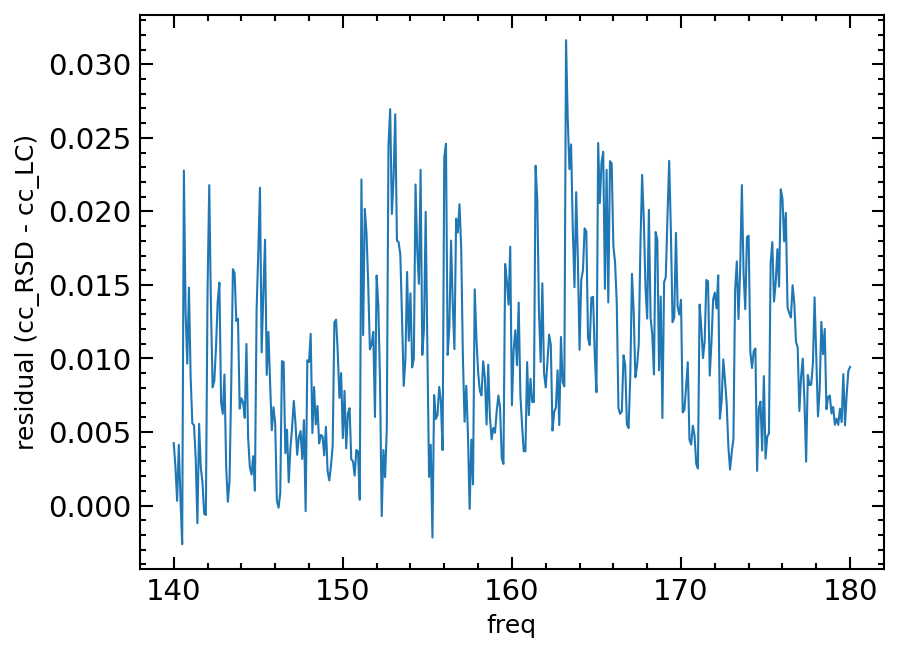

In [15]:
c = 4

model1, resids_LC_FG_NOISE = do_fastica(FG_LC_NOISE, c)

model2, resids_RSD_FG_NOISE = do_fastica(FG_RSD_NOISE, c)

print('correlation between model from each lc {}'.format(pearson_correl(model1,model2)))

correlation_graph(LC_NOISE, RSD_NOISE, resids_LC_FG_NOISE, resids_RSD_FG_NOISE, freq, 'EoR_NOISE_4c_fastica_recovery_corre.pdf')

In [16]:
Pk_NOISE, mubins_NOISE, kbins_NOISE, nmode_NOISE = t2c.power_spectrum_mu(NOISE[:,:,i0:i1],  box_dims=box_dims, los_axis = 2, mubins=mubins,kbins=kbins, exclude_zero_modes=True,return_n_modes=True,absolute_mus=False)
dk_NOISE = (Pk_NOISE*kbins_NOISE**3)/(2*np.pi**2)

In [17]:
i0 = 0
i1 = 101  

L_para, L_perp = get_lengths(freq[i0], freq[i1], (freq[i0]+freq[i1])/2, 1.0)
box_dims = [L_perp, L_perp, L_para]

V_eor = L_perp*L_perp*L_para
"""
Pk_1, mubins_1, kbins_1, nmode_1 = t2c.power_spectrum_mu(LC_z01_nu01_1deg[:,:,i0:i1], box_dims=box_dims, los_axis = 2, mubins=mubins,kbins=kbins, exclude_zero_modes=True,return_n_modes=True,absolute_mus=False)
Pk_res1, mubins_res1, kbins_res1, nmode_res1 = t2c.power_spectrum_mu(resids_LC_FG_NOISE[:,:,i0:i1], box_dims=box_dims, los_axis = 2, mubins=mubins,kbins=kbins, exclude_zero_modes=True,return_n_modes=True,absolute_mus=False)

Pk_rsd, mubins_rsd, kbins_rsd, nmode_rsd = t2c.power_spectrum_mu(RSD_z01_nu01_1deg[:,:,i0:i1], box_dims=box_dims, los_axis = 2, mubins=mubins,kbins=kbins, exclude_zero_modes=True,return_n_modes=True,absolute_mus=False)
Pk_resrsd, mubins_resrsd, kbins_resrsd, nmode_resrsd = t2c.power_spectrum_mu(resids_RSD_FG_NOISE[:,:,i0:i1], box_dims=box_dims, los_axis = 2, mubins=mubins,kbins=kbins, exclude_zero_modes=True,return_n_modes=True,absolute_mus=False)
    """




'\nPk_1, mubins_1, kbins_1, nmode_1 = t2c.power_spectrum_mu(LC_z01_nu01_1deg[:,:,i0:i1], box_dims=box_dims, los_axis = 2, mubins=mubins,kbins=kbins, exclude_zero_modes=True,return_n_modes=True,absolute_mus=False)\nPk_res1, mubins_res1, kbins_res1, nmode_res1 = t2c.power_spectrum_mu(resids_LC_FG_NOISE[:,:,i0:i1], box_dims=box_dims, los_axis = 2, mubins=mubins,kbins=kbins, exclude_zero_modes=True,return_n_modes=True,absolute_mus=False)\n\nPk_rsd, mubins_rsd, kbins_rsd, nmode_rsd = t2c.power_spectrum_mu(RSD_z01_nu01_1deg[:,:,i0:i1], box_dims=box_dims, los_axis = 2, mubins=mubins,kbins=kbins, exclude_zero_modes=True,return_n_modes=True,absolute_mus=False)\nPk_resrsd, mubins_resrsd, kbins_resrsd, nmode_resrsd = t2c.power_spectrum_mu(resids_RSD_FG_NOISE[:,:,i0:i1], box_dims=box_dims, los_axis = 2, mubins=mubins,kbins=kbins, exclude_zero_modes=True,return_n_modes=True,absolute_mus=False)\n    '

dk_lc = (Pk_1*V_eor*kbins_1**3)/(2*np.pi**2)
dk_rsd_lc = (Pk_rsd*V_eor*kbins_rsd**3)/(2*np.pi**2)
dk_lc_res = (Pk_res1*V_eor*kbins_res1**3)/(2*np.pi**2)
dk_rsd_res = (Pk_resrsd*V_eor*kbins_resrsd**3)/(2*np.pi**2)

dk_rsd_res1 = dk_rsd_res - dk_NOISE
dk_lc_res1 = dk_lc_res - dk_NOISE

#calculate errors
err_lc_res= np.empty_like(nmode_res1)
err_rsd_res= np.empty_like(nmode_res1)
err_noise = np.empty_like(nmode_res1)

print(nmode_res1.shape)

standard_noise_error = 1/np.sqrt(nmode_NOISE)
#calculate errors
errors = np.loadtxt(base + 'errors_on_FastICA_EoR_mups.txt')
errors = errors.reshape((mubins,kbins,3))
err_lc_res= errors[:,:,1]
err_rsd_res= errors[:,:,0]
err_noise = errors[:,:,2]
        
        
ii = 4
jj = 4

fig, ax = plt.subplots(figsize=(fig_width, fig_height),
                       nrows=2, ncols=1,)



ax[0].plot(mubins_1, dk_lc[:,ii], color='k', label=r'$\delta T_b(21\rm cm)$')
ax[0].errorbar(mubins_res1, dk_lc_res1[:,ii], yerr= err_lc_res[:,ii], color='k', linestyle='none', marker='x', label=r'$\delta T_b(\rm reconstructed)$', capsize=2.5)
ax[0].plot(mubins_rsd, dk_rsd_lc[:,ii], color='r')
ax[0].errorbar(mubins_resrsd, dk_rsd_res1[:,ii], yerr= err_rsd_res[:,ii], color='r', linestyle='none', marker='x', capsize=2.5)
ax[0].errorbar(mubins_NOISE, dk_NOISE[:,ii], err_noise[:,ii], color='darkviolet', linestyle='dashdot', capsize=2.5)
#ax[0].plot(mubins_rsd, err_noise[:,ii], color='g', linestyle='dashed', alpha=0.5)
ax[0].set_yscale('log')
ax[0].set_xlabel(r'$\mu$', fontsize=16)
ax[0].set_ylabel(r'$\Delta^2_{\rm 3D}(k,\mu)/ \rm mK^2$', fontsize=16)
ax[0].text(0.5, 0.15, r' $k={0:.2f}$'.format(kbins_1[ii]), transform=ax[0].transAxes, ha='right', va='top', fontsize=14)
ax[0].legend(frameon=False, fontsize = 14, ncol=2)
ax[0].set_ylim(top = 10000000000)
 
ax[1].plot(kbins_1, dk_lc[jj,:], color='k') 
ax[1].errorbar(kbins_res1, dk_lc_res1[jj,:], yerr= err_lc_res[jj,:], color='k', linestyle='none', marker='x', capsize=2.5)
ax[1].plot(kbins_rsd, dk_rsd_lc[jj,:], color='r')
ax[1].errorbar(kbins_resrsd, dk_rsd_res1[jj,:], yerr= err_rsd_res[jj,:], color='r', linestyle='none', marker='x', capsize=2.5)
ax[1].errorbar(kbins_NOISE, dk_NOISE[jj,:], err_noise[jj,:], color='darkviolet', linestyle='dashdot', capsize=2.5)
#ax[1].plot(kbins_NOISE, err_noise[jj,:], color='g', label='noise error', linestyle='dashed', alpha=0.5)
ax[1].set_xlabel(r'$k/(\rm Mpc/h)^{-1}$', fontsize=16)
ax[1].set_ylabel(r'$\Delta^2_{\rm 3D}(k,\mu)/ \rm mK^2$', fontsize=16)
ax[1].text(0.95, 0.5, r' $\mu={0:.2f}$'.format(mubins_resrsd[jj]), transform=ax[1].transAxes, ha='right', va='top', fontsize=14)
ax[1].set_yscale('log')
ax[1].set_xscale('log')
plt.tight_layout()
plt.savefig(base + 'graphs_for_paper/EoR_Fg_4c_fastica_recovery_mu_allks_NOISE_all_stations.pdf', dpi=330, bbox_inches='tight')
plt.show()

print(err_noise - standard_noise_error)

print(dk_rsd_res[jj, 12])
print((np.abs(dk_rsd_res[jj, 12]-dk_lc_res[jj, 12])/dk_lc_res[jj, 12])*100)
print((np.abs(dk_rsd_lc[jj, 12]-dk_lc[jj, 12])/dk_lc[jj, 12])*100)

print(dk_rsd_res1[jj, 12])
print((np.abs(dk_rsd_res1[jj, 12]-dk_lc_res1[jj, 12])/dk_lc_res1[jj,12])*100)
print((np.abs(dk_rsd_lc[jj, 12]-dk_lc[jj, 12])/dk_lc[jj, 12])*100)

In [19]:

p_lc_eor_res, k_lc_eor_res, n_lc_res = t2c.power_spectrum_1d(resids_LC_FG_NOISE[:,:,i0:i1],  box_dims=box_dims, kbins=kbins, binning = 'log', return_n_modes=True)
p_rsd_lc_eor_res, k_rsd_lc_eor_res, n_rsd_res = t2c.power_spectrum_1d(resids_RSD_FG_NOISE[:,:,i0:i1],  box_dims=box_dims, kbins=kbins, binning = 'log', return_n_modes=True)
p_lc_eor, k_lc_eor, n_lc = t2c.power_spectrum_1d(LC_z01_nu01_1deg[:,:,i0:i1],  box_dims=box_dims, kbins=kbins, binning = 'log', return_n_modes=True)
p_rsd_lc_eor, k_rsd_lc_eor, n_rsd = t2c.power_spectrum_1d(RSD_z01_nu01_1deg[:,:,i0:i1],  box_dims=box_dims, kbins=kbins, binning = 'log', return_n_modes=True)
        
d_lc_eor = (p_lc_eor*k_lc_eor**3)/(2*np.pi**2)
d_rsd_lc_eor = (p_rsd_lc_eor*k_rsd_lc_eor**3)/(2*np.pi**2)
d_lc_eor_res = (p_lc_eor_res*k_lc_eor_res**3)/(2*np.pi**2)
d_rsd_lc_eor_res = (p_rsd_lc_eor_res*k_rsd_lc_eor_res**3)/(2*np.pi**2)



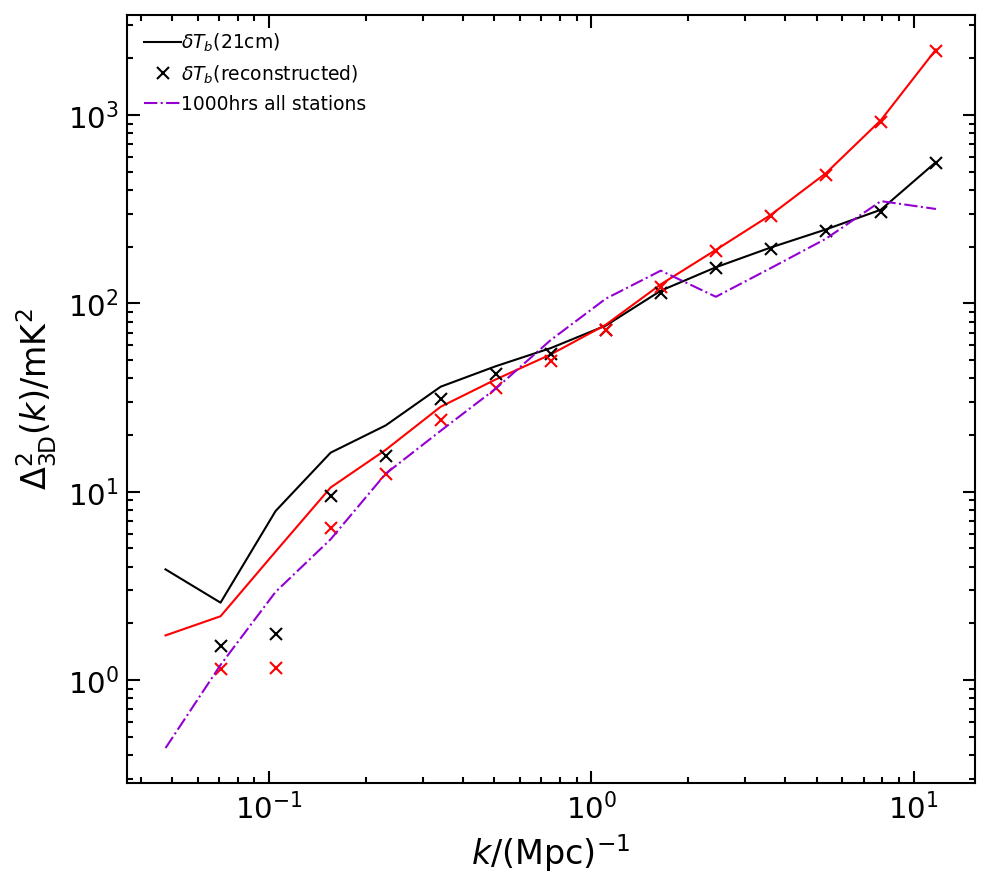

[5.40059039e+06 1.04204685e+07 1.55600634e+07 2.28064215e+07
 2.27732987e+07 3.01656294e+07 3.41534199e+07 3.67971127e+07
 4.38121958e+07 4.28782629e+07 1.11860934e+05 1.46805666e+04
 7.13580334e+03 5.56194093e+03 2.73415609e+03]


In [20]:
d_rsd_res = d_rsd_lc_eor_res - d_NOISE
d_lc_res = d_lc_eor_res - d_NOISE

#calculate errors

#calculate errors
errors = np.loadtxt(base + 'errors_on_FastICA_EoR_1Dps.txt')
e_lc_res= errors[:,1]
e_rsd_res= errors[:,0]
e_noise = errors[:,2]
        

fig, ax = plt.subplots(figsize=(fig_width, fig_height),
                       nrows=1, ncols=1)
ax.plot(k_lc_eor, d_lc_eor, color='k', label=r'$\delta T_b(21\rm cm)$') 
ax.plot(k_rsd_lc_eor, d_rsd_lc_eor, color='r')
ax.plot(k_lc_eor_res, d_lc_res, color='k', linestyle='none', marker='x', label=r'$\delta T_b(\rm reconstructed)$')
ax.plot(k_rsd_lc_eor_res, d_rsd_res, linestyle='none', marker='x', color='r')
ax.plot(k_NOISE, d_NOISE, color='darkviolet', linestyle='dashdot', label='1000hrs all stations')
"""ax.errorbar(k_lc_eor_res, d_lc_res, e_lc_res, color='k', linestyle='none', capsize=2.5, marker='x', label=r'$\delta T_b(\rm reconstructed)$')
ax.errorbar(k_rsd_lc_eor_res, d_rsd_res, e_rsd_res, linestyle='none', capsize=2.5, marker='x', color='r')
ax.errorbar(k_NOISE, d_NOISE, e_noise, capsize=2.5, color='darkviolet', linestyle='dashdot')"""
#ax.plot(k_NOISE_2000, d_NOISE_2000, color='pink', linestyle='dashdot', label='2000hrs all stations')
#ax.plot(k_NOISE2, d_NOISE2, capsize=2.5, color='g', linestyle='dashdot')
#ax.plot(k_NOISE, e_noise, color='g', linestyle='dashed', alpha=0.5)
ax.set_ylabel(r'$\Delta_{\rm 3D} ^2(k)/\rm mK^2$', fontsize=16)
ax.set_xlabel(r'$k/(\rm Mpc)^{-1}$', fontsize=16)
ax.set_yscale('log')
ax.set_xscale('log')
ax.legend(frameon=False, fontsize = 14)
#ax.set_ylim(bottom = 1000000)
plt.legend()
plt.tight_layout()
plt.savefig(base + 'graphs_for_paper/EoR_Fg_4c_fastica_recovery_1Dps_NOISE_all_stations.pdf', dpi=330, bbox_inches='tight')
plt.show()

standard_noise_error = 1/np.sqrt(n_NOISE)
print(e_noise - standard_noise_error)

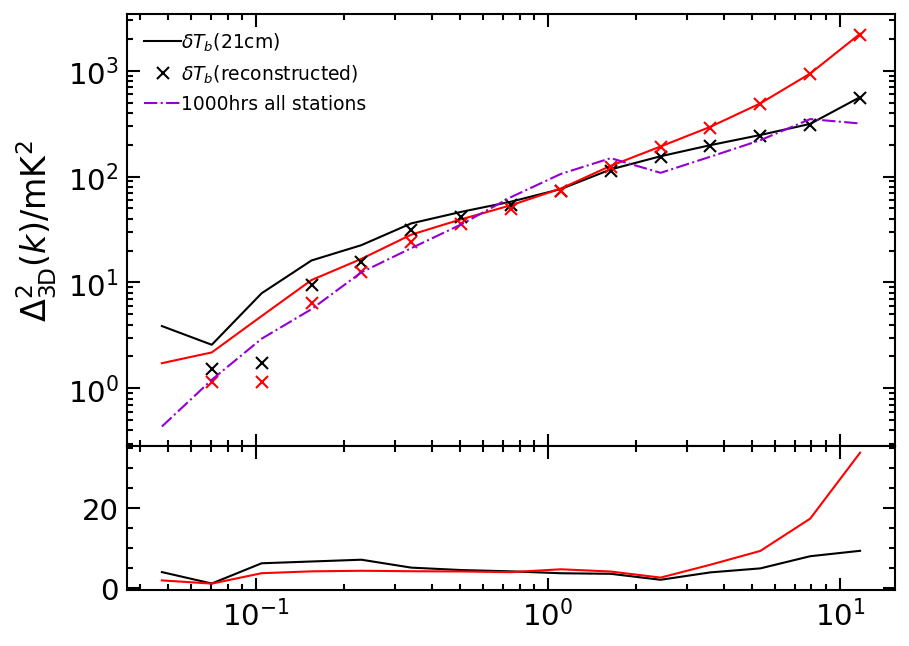

In [27]:
#plot with residual panel
#PLOT
fig1 = plt.figure(1)
#Plot Data-model
frame1=fig1.add_axes((.1,.3,.8,.6))
plt.plot(k_lc_eor, d_lc_eor, color='k', label=r'$\delta T_b(21\rm cm)$') 
plt.plot(k_rsd_lc_eor, d_rsd_lc_eor, color='r')
plt.plot(k_lc_eor_res, d_lc_res, color='k', linestyle='none', marker='x', label=r'$\delta T_b(\rm reconstructed)$')
plt.plot(k_rsd_lc_eor_res, d_rsd_res, linestyle='none', marker='x', color='r')
plt.plot(k_NOISE, d_NOISE, color='darkviolet', linestyle='dashdot', label='1000hrs all stations')
plt.ylabel(r'$\Delta_{\rm 3D} ^2(k)/\rm mK^2$', fontsize=16)
plt.xlabel(r'$k/(\rm Mpc)^{-1}$', fontsize=16)
plt.yscale('log')
plt.xscale('log')
plt.legend()
#Residual plot
frame2=fig1.add_axes((.1,.1,.8,.2))        
plt.plot(k_lc_eor,d_lc_eor-d_lc_res,'k')  
plt.plot(k_rsd_lc_eor,d_rsd_lc_eor-d_rsd_res,'r')  
plt.xscale('log')
plt.tight_layout()
#plt.savefig(base + 'graphs_for_paper/EoR_Fg_4c_fastica_recovery_1Dps_NOISE_all_stations.pdf', dpi=330, bbox_inches='tight')
plt.show()

In [ ]:
print((np.abs(d_rsd_lc_eor[-1]-d_lc_eor[-1])/d_lc_eor[-1])*100)
print((np.abs(d_rsd_res[-1]-d_lc_res[-1])/d_lc_res[-1])*100)

296.33688029152495
293.22043721373876


from scipy import interpolate
import matplotlib.colors as colors

plotting_scale={'x': 'log', 'y': 'log', 'z': 'log'}

bins = 8
  
i0 = 0
i1 = 101  

L_para, L_perp = get_lengths(freq[i0], freq[i1], (freq[i0]+freq[i1])/2, 1.0)
box_dims = [L_perp, L_perp, L_para]

V_eor = L_perp*L_perp*L_para

pp_NOISE, kper_NOISE, kpar_NOISE, n_NOISE = t2c.power_spectrum_2d(NOISE[:,:,i0:i1], kbins=bins, box_dims= box_dims, return_modes=True)
for ii in range(0,len(kper_NOISE)):
    for jj in range(0,len(kpar_NOISE)):
        pp_NOISE[ii,jj] = (pp_NOISE[ii,jj]*V_eor*np.sqrt(kper_NOISE[ii]**2 + kpar_NOISE[jj]**2)**3)/(2*np.pi**2)
        
fp_NOISE = interpolate.interp2d(kper_NOISE, kpar_NOISE, pp_NOISE.T, kind='linear')
X_NOISE, Y_NOISE = kper_NOISE, kpar_NOISE
C_NOISE = fp_NOISE(X_NOISE,Y_NOISE)
norm_NOISE = colors.LogNorm(vmin=C_NOISE[np.isfinite(C_NOISE)].min(), vmax=C_NOISE[np.isfinite(C_NOISE)].max()) if plotting_scale['z']=='log' else None 


pp_RSD_RES, kper_RSD_RES, kpar_RSD_RES, n_RSD_RES = t2c.power_spectrum_2d(resids_RSD_FG_NOISE[:,:,i0:i1], kbins=bins, box_dims= box_dims, return_modes=True)
for ii in range(0,len(kper_RSD_RES)):
    for jj in range(0,len(kpar_RSD_RES)):
        pp_RSD_RES[ii,jj] = (pp_RSD_RES[ii,jj]*V_eor*np.sqrt(kper_RSD_RES[ii]**2 + kpar_RSD_RES[jj]**2)**3)/(2*np.pi**2)
err_RSD_RES = 1/np.sqrt(n_RSD_RES)
fp_RSD_RES = interpolate.interp2d(kper_RSD_RES, kpar_RSD_RES, pp_RSD_RES.T, kind='linear')
X_RSD_RES, Y_RSD_RES = kper_RSD_RES, kpar_RSD_RES
C_RSD_RES = fp_RSD_RES(X_RSD_RES,Y_RSD_RES)
C_RSD_RES = C_RSD_RES - C_NOISE
norm_RSD_RES = colors.LogNorm(vmin=C_RSD_RES[np.isfinite(C_RSD_RES)].min(), vmax=C_RSD_RES[np.isfinite(C_RSD_RES)].max()) if plotting_scale['z']=='log' else None 


pp_LC_RES, kper_LC_RES, kpar_LC_RES, n_LC_RES = t2c.power_spectrum_2d(resids_LC_FG_NOISE[:,:,i0:i1], kbins=bins, box_dims= box_dims, return_modes=True)
for ii in range(0,len(kper_LC_RES)):
    for jj in range(0,len(kpar_LC_RES)):
        pp_LC_RES[ii,jj] = (pp_LC_RES[ii,jj]*V_eor*np.sqrt(kper_LC_RES[ii]**2 + kpar_LC_RES[jj]**2)**3)/(2*np.pi**2)
err_LC_RES = 1/np.sqrt(n_LC_RES)
fp_LC_RES = interpolate.interp2d(kper_LC_RES, kpar_LC_RES, pp_LC_RES.T, kind='linear')
X_LC_RES, Y_LC_RES = kper_LC_RES, kpar_LC_RES
C_LC_RES = fp_LC_RES(X_LC_RES,Y_LC_RES)
C_LC_RES = C_LC_RES - C_NOISE
norm_LC_RES = colors.LogNorm(vmin=C_LC_RES[np.isfinite(C_LC_RES)].min(), vmax=C_LC_RES[np.isfinite(C_LC_RES)].max()) if plotting_scale['z']=='log' else None 

pp_RSD, kper_RSD, kpar_RSD, n_RSD = t2c.power_spectrum_2d(RSD_z01_nu01_1deg[:,:,i0:i1], kbins=bins, box_dims= box_dims, return_modes=True)
for ii in range(0,len(kper_RSD)):
    for jj in range(0,len(kpar_RSD)):
        pp_RSD[ii,jj] = (pp_RSD[ii,jj]*V_eor*np.sqrt(kper_RSD[ii]**2+kpar_RSD[jj]**2)**3)/(2*np.pi**2)

fp_RSD = interpolate.interp2d(kper_RSD, kpar_RSD, pp_RSD.T, kind='linear')
X_RSD, Y_RSD = kper_RSD, kpar_RSD
C_RSD = fp_RSD(X_RSD,Y_RSD)
norm_RSD = colors.LogNorm(vmin=C_RSD[np.isfinite(C_RSD)].min(), vmax=C_RSD[np.isfinite(C_RSD)].max()) if plotting_scale['z']=='log' else None 

pp_LC, kper_LC, kpar_LC, n_LC = t2c.power_spectrum_2d(LC_z01_nu01_1deg[:,:,i0:i1], kbins=bins, box_dims= box_dims, return_modes=True)
for ii in range(0,len(kper_LC)):
    for jj in range(0,len(kpar_LC)):
        pp_LC[ii,jj] = (pp_LC[ii,jj]*V_eor*np.sqrt(kper_LC[ii]**2 + kpar_LC[jj]**2)**3)/(2*np.pi**2)
        
fp_LC = interpolate.interp2d(kper_LC, kpar_LC, pp_LC.T, kind='linear')
X_LC, Y_LC = kper_LC, kpar_LC
C_LC = fp_LC(X_LC,Y_LC)
norm_LC = colors.LogNorm(vmin=C_LC[np.isfinite(C_LC)].min(), vmax=C_LC[np.isfinite(C_LC)].max()) if plotting_scale['z']=='log' else None 

C_diff = (np.abs(C_RSD - C_LC)/C_LC)*100
norm_diff = colors.LogNorm(vmin=C_diff[np.isfinite(C_diff)].min(), vmax=C_diff[np.isfinite(C_diff)].max()) if plotting_scale['z']=='log' else None 

C_diff_res =  (np.abs(C_RSD_RES - C_LC_RES)/C_LC_RES)*100
norm_diff_res = colors.LogNorm(vmin=C_diff_res[np.isfinite(C_diff_res)].min(), vmax=C_diff_res[np.isfinite(C_diff_res)].max()) if plotting_scale['z']=='log' else None 

highlighted_pixels = np.zeros([2,14])
uu=0
for ii in range(0, C_RSD_RES.shape[0]):
    for jj in range(0, C_RSD_RES.shape[1]):
        if C_RSD_RES[ii,jj] <= 0:
            highlighted_pixels[0,uu] = ii
            highlighted_pixels[1,uu] = jj
            C_RSD_RES[ii,jj] = 1e5
            uu+=1
        else:
            continue
        
for ii in range(0, C_LC_RES.shape[0]):
    for jj in range(0, C_LC_RES.shape[1]):
        if C_LC_RES[ii,jj] <= 0:
            C_LC_RES[ii,jj] = 1e5
        else:
            continue
        
C_tot = np.concatenate((C_LC, C_RSD, C_LC_RES, C_RSD_RES))
norm_tot = colors.LogNorm(vmin=C_tot[np.isfinite(C_tot)].min(), vmax=C_tot[np.isfinite(C_tot)].max()) if plotting_scale['z']=='log' else None

print(pearson_correl(C_diff_res.reshape(8*8),C_diff.reshape(8*8)))

for ii in range(0, C_diff_res.shape[0]):
    for jj in range(0, C_diff_res.shape[1]):
        if C_diff_res[ii,jj] <= 0:
            C_diff_res[ii,jj] =  0.1
        else:
            continue
        
        

        
        
C_tot_diff = np.concatenate((C_diff, C_diff_res))
norm_tot_diff = colors.LogNorm(vmin=C_tot_diff[np.isfinite(C_tot_diff)].min(), vmax=C_tot_diff[np.isfinite(C_tot_diff)].max()) if plotting_scale['z']=='log' else None 

#calculate errors
errors = np.loadtxt(base + 'errors_on_FastICA_EoR_cyclindricalps.txt')
errors = errors.reshape((bins,bins,2))
err_lc= errors[:,:,0]
err_rsd= errors[:,:,1]

noise_pixels_LC= np.zeros([2,16])
uu=0
print(C_LC.shape)
for ii in range(0, C_LC.shape[0]):
    for jj in range(0, C_LC.shape[1]):
        if err_lc[ii,jj] >= C_LC[ii,jj]:
            noise_pixels_LC[0,uu] = ii
            noise_pixels_LC[1,uu] = jj
            uu+=1
        else:
            continue
        
noise_pixels_RSD= np.zeros([2,16])
uu=0
for ii in range(0, C_RSD.shape[0]):
    for jj in range(0, C_RSD.shape[1]):
        if err_rsd[ii,jj] >= C_RSD[ii,jj]:
            noise_pixels_RSD[0,uu] = ii
            noise_pixels_RSD[1,uu] = jj
            uu+=1
        else:
            continue

import matplotlib.patches as patches
import matplotlib.font_manager
import matplotlib as mpl


fig, ax = plt.subplots(figsize=(2*fig_width, fig_height),
                       nrows=2, ncols=3,)
    
pcm_RSD = ax[0,0].pcolormesh(X_RSD, Y_RSD, C_RSD, norm=norm_tot, cmap='inferno')
cbar= plt.colorbar(pcm_RSD, ax=ax[0,0], pad=0.01)
cbar.set_label(r'$\Delta^2_{\rm 3D}(k_{\parallel}, k_{\perp}) /\rm mK^2 $', size=16) 
ax[0,0].set_xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$', fontsize = 14)
ax[0,0].set_ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$', fontsize = 14)
ax[0,0].set_xscale(plotting_scale['x'])
ax[0,0].set_yscale(plotting_scale['y'])
  

pcm_LC = ax[0,1].pcolormesh(X_LC, Y_LC, C_LC, norm=norm_tot, cmap='inferno')
cbar= plt.colorbar(pcm_LC, ax=ax[0,1], pad=0.01)
cbar.set_label(r'$\Delta^2_{\rm 3D}(k_{\parallel}, k_{\perp}) /\rm mK^2 $', size=16) 
ax[0,1].set_xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$', fontsize = 14)
ax[0,1].set_ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$', fontsize = 14)
ax[0,1].set_xscale(plotting_scale['x'])
ax[0,1].set_yscale(plotting_scale['y'])
   

pcm_LC = ax[0,2].pcolormesh(X_LC, Y_LC, C_diff, norm=norm_tot_diff, cmap='inferno')
cbar= plt.colorbar(pcm_LC, ax=ax[0,2], pad=0.01)
cbar.set_label(r'$[|\Delta^2_{\rm full} - \Delta^2_{\rm std.}|/\Delta^2_{\rm std.}] \times 100 $', size=14)
ax[0,2].set_xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$', fontsize = 14)
ax[0,2].set_ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$', fontsize = 14)
ax[0,2].set_xscale(plotting_scale['x'])
ax[0,2].set_yscale(plotting_scale['y'])
    

pcm_RSD_RES = ax[1,0].pcolormesh(X_RSD_RES, Y_RSD_RES, C_RSD_RES, norm=norm_tot, cmap='inferno')
cbar= plt.colorbar(pcm_RSD_RES, ax=ax[1,0], pad=0.01)
cbar.set_label(r'$\Delta^2_{\rm 3D}(k_{\parallel}, k_{\perp}) /\rm mK^2 $', size=16) 
ax[1,0].set_xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$', fontsize = 14)
ax[1,0].set_ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$', fontsize = 14)
ax[1,0].set_xscale(plotting_scale['x'])
ax[1,0].set_yscale(plotting_scale['y'])


pcm_LC_RES = ax[1,1].pcolormesh(X_LC_RES, Y_LC_RES, C_LC_RES, norm=norm_tot, cmap='inferno')
cbar= plt.colorbar(pcm_LC_RES, ax=ax[1,1], pad=0.01)
cbar.set_label(r'$\Delta^2_{\rm 3D}(k_{\parallel}, k_{\perp}) /\rm mK^2 $', size=16) 
ax[1,1].set_xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$', fontsize = 14)
ax[1,1].set_ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$', fontsize = 14)
ax[1,1].set_xscale(plotting_scale['x'])
ax[1,1].set_yscale(plotting_scale['y'])
    

pcm_LC_RES = ax[1,2].pcolormesh(X_LC_RES, Y_LC_RES, C_diff_res, norm=norm_tot_diff, cmap='inferno') 
cbar= plt.colorbar(pcm_LC_RES, ax=ax[1,2], pad=0.01)
cbar.set_label(r'$[|\Delta^2_{\rm full} - \Delta^2_{\rm std.}|/\Delta^2_{\rm std.}] \times 100 $', size=14)

"""# Compute bin edges from centers
x_edges = np.sqrt(X_LC_RES[:-1] * X_LC_RES[1:])
x_edges = np.concatenate(([X_LC_RES[0]**2 / X_LC_RES[1]], x_edges, [X_LC_RES[-1]**2 / X_LC_RES[-2]]))

y_edges = np.sqrt(Y_LC_RES[:-1] * Y_LC_RES[1:])
y_edges = np.concatenate(([0.032], y_edges, [1.5]))
for row, col in highlighted_pixels.T:
    col = int(col)
    row = int(row)
    x_start = x_edges[col]      # Left edge
    y_start = y_edges[row]      # Bottom edge
    x_end = x_edges[col + 1]    # Right edge
    y_end = y_edges[row + 1]    # Top edge

    width = x_end - x_start
    height = y_end - y_start

    rect = patches.Rectangle((x_start, y_start), width, height,
                             linewidth=2, edgecolor='red', facecolor='none')
    ax[1,2].add_patch(rect)
    
    
#add in level of noise error
for row, col in noise_pixels_RSD.T:
    col = int(col)
    row = int(row)
    x_start = x_edges[col]      # Left edge
    y_start = y_edges[row]      # Bottom edge
    x_end = x_edges[col + 1]    # Right edge
    y_end = y_edges[row + 1]    # Top edge

    width = x_end - x_start
    height = y_end - y_start

    rect = patches.Rectangle((x_start, y_start), width, height,
                             linewidth=2, edgecolor='green', facecolor='none')
    ax[1,0].add_patch(rect)
    
#add in level of noise error
for row, col in noise_pixels_RSD.T:
    col = int(col)
    row = int(row)
    x_start = x_edges[col]      # Left edge
    y_start = y_edges[row]      # Bottom edge
    x_end = x_edges[col + 1]    # Right edge
    y_end = y_edges[row + 1]    # Top edge

    width = x_end - x_start
    height = y_end - y_start

    rect = patches.Rectangle((x_start, y_start), width, height,
                             linewidth=2, edgecolor='green', facecolor='none')
    ax[1,1].add_patch(rect)"""
    

ax[1,2].set_xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$', fontsize = 14)
ax[1,2].set_ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$', fontsize = 14)
ax[1,2].set_xscale(plotting_scale['x'])
ax[1,2].set_yscale(plotting_scale['y'])
    
plt.tight_layout()
plt.savefig(base + 'graphs_for_paper/cyclindrical_powerSpec_FGremoval_512_160-170MHz_NOISE_all_stations.pdf', dpi=330, bbox_inches='tight')
plt.show()